In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_columns = None

from datetime import datetime, date, timezone
from dateutil.relativedelta import relativedelta
import time
import random

import pandas_ta as ta

import yfinance as yf
import requests

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (18, 9)
plt.rcParams["figure.autolayout"] = True

from ta.volatility import BollingerBands
from ta.trend import ADXIndicator
from ta.momentum import StochasticOscillator

from pmdarima import auto_arima
# from get_data import DataMaker  # самодельная библиотека для сбора датасетов
# from ml_models import *

from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM, GRU, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
    roc_auc_score,
    precision_score,
    recall_score,
)


from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore')

In [3]:
def fetch_binance_data(
        symbols: dict,
        start_date="2020-01-01", 
        end_date=None, 
        interval: str='5m',
        limit_per_request=1000
):
    """
    Улучшенная версия с проверкой доступных пар и обработкой ошибок
    
    Параметры:
    symbols - словарь {название_инструмента: пара_торгов}
    start_date - начальная дата (str или datetime)
    end_date - конечная дата (по умолчанию текущее время)
    interval - таймфрейм ('1m', '5m', '1h', '1d')
    limit_per_request - лимит свечей на запрос (макс. 1000)
    """
    if end_date is None:
        end_date = datetime.now()
    elif isinstance(end_date, str):
        end_date = pd.to_datetime(end_date)
        
    if isinstance(start_date, str):
        start_date = pd.to_datetime(start_date)
    
    # Конвертируем даты в timestamp (миллисекунды)
    start_timestamp = int(start_date.timestamp() * 1000)
    end_timestamp = int(end_date.timestamp() * 1000)
    
    url = "https://api.binance.com/api/v3/klines"
    all_data = {symbol: [] for symbol in symbols.keys()}

    for symbol_name, symbol_pair in symbols.items():
        print(f"\nСбор данных для {symbol_name} ({symbol_pair})...")
        current_start = start_timestamp
        
        while current_start < end_timestamp:
            time.sleep(0.3)  # Вежливая задержка между запросами
            
            params = {
                "symbol": symbol_pair,
                "interval": interval,
                "startTime": current_start,
                "endTime": end_timestamp,
                "limit": limit_per_request
            }
            
            try:
                response = requests.get(url, params=params)
                
                # Проверяем код ответа
                if response.status_code == 400:
                    print(f"Пара {symbol_pair} не найдена на Binance. Пропускаем.")
                    break
                    
                response.raise_for_status()
                data = response.json()

                if not data:
                    break  

                all_data[symbol_name].extend(data)
                last_candle_time = data[-1][0]
                current_start = last_candle_time + 1  # +1 мс чтобы избежать дублирования

                last_date = pd.to_datetime(last_candle_time, unit='ms').strftime('%Y-%m-%d %H:%M')
                print(f"Получены данные до {last_date}", end='\r')
                
            except Exception as e:
                print(f"\nОшибка при получении данных для {symbol_pair}: {str(e)[:100]}...")
                break

    # Создаем DataFrame для каждого инструмента
    dfs = []
    columns = [
        "Open time", "Open", "High", "Low", "Close", "Volume",
        "Close time", "Quote volume", "Trades count",
        "Taker buy base volume", "Taker buy quote volume", "Ignore"
    ]
    
    for symbol_name, data in all_data.items():
        if not data:
            print(f"\nНет данных для {symbol_name}")
            continue
            
        df = pd.DataFrame(data, columns=columns).drop(columns=["Close time", "Ignore"])
        df['Date'] = pd.to_datetime(df['Open time'], unit='ms')
        
        # Отбираем и переименовываем нужные колонки
        price_cols = ["Open", "High", "Low", "Close", "Volume", 
                      
                      "Quote volume", "Trades count", 
                      "Taker buy base volume", "Taker buy quote volume"]
        new_cols = {col: f"{symbol_name}_{col}" for col in price_cols}
        
        df = df[['Date'] + price_cols].rename(columns=new_cols)
        
        # Конвертируем числовые колонки
        for col in price_cols:
            df[f"{symbol_name}_{col}"] = pd.to_numeric(df[f"{symbol_name}_{col}"])
        
        dfs.append(df)
    
    # Объединяем все данные по дате
    if not dfs:
        return pd.DataFrame()
    
    merged_df = dfs[0]
    for df in dfs[1:]:
        merged_df = pd.merge(merged_df, df, on='Date', how='outer')
    
    # Сортируем по дате и удаляем дубликаты
    merged_df = merged_df.sort_values('Date').drop_duplicates('Date')
    
    return merged_df

# Проверенные доступные пары с низкой корреляцией
symbols = {
    'BTC':  'BTCUSDT',
    'ETH':  'ETHUSDT',
    
    'USDT': 'USDTBUSD',
    'USDC': 'USDCUSDT',

    "STX":  "STXUSDT",     # Stacks
    "PAXG": "PAXGUSDT",    # токенизированное золото
    "FDUSD":"FDUSDUSDT",   # новый стейблкоин Binance
    "TUSD": "TUSDUSDT",    # централизованный стейблкоин
}
# Пример использования
start_date = "2023-08-01"
end_date = datetime.now().strftime("%Y-%m-%d %H:%M")

print(f"\nСбор данных с {start_date} по {end_date}...")
df = fetch_binance_data(symbols, start_date=start_date, end_date=end_date, interval='5m')
df.columns = df.columns.str.replace(' ', '_')
df.set_index('Date', inplace=True)

if not df.empty:
    filename = f"crypro_from_{start_date[:10]}_to_{end_date[:10]}.csv"
    df.to_csv(filename, index=False)
    print(f"\nДанные сохранены в файл: {filename}")
else:
    print("\nНе удалось получить данные для указанных инструментов")


Сбор данных с 2023-08-01 по 2025-06-13 20:22...

Сбор данных для BTC (BTCUSDT)...
Получены данные до 2025-06-13 17:25
Сбор данных для ETH (ETHUSDT)...
Получены данные до 2025-06-13 17:30
Сбор данных для USDT (USDTBUSD)...
Пара USDTBUSD не найдена на Binance. Пропускаем.

Сбор данных для USDC (USDCUSDT)...
Получены данные до 2025-06-13 17:30
Сбор данных для STX (STXUSDT)...
Получены данные до 2025-06-13 17:35
Сбор данных для PAXG (PAXGUSDT)...
Получены данные до 2025-06-13 17:40
Сбор данных для FDUSD (FDUSDUSDT)...
Получены данные до 2025-06-13 17:40
Сбор данных для TUSD (TUSDUSDT)...
Получены данные до 2025-06-13 17:45
Нет данных для USDT

Данные сохранены в файл: crypro_from_2023-08-01_to_2025-06-13.csv


In [9]:
usd = fetch_binance_data(
    {'USDT': 'USDCUSDT'}, 
    start_date=start_date, 
    end_date=end_date, 
    interval='5m'
)



Сбор данных для USDT (USDCUSDT)...


In [79]:
import pandas as pd
import pandas_ta as ta
import numpy as np
from arch import arch_model
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def prepare_df(
    df: pd.DataFrame,
    symbol: str = 'FDUSD',
    price_type: str = 'Low',
    target_type: int = 1
) -> pd.DataFrame:
    """
    Добавляет в df:
    - бинарный таргет по росту таргетного столбца за 15 минут (3 бара);
    - лаги и процентные изменения;
    - все скользящие средние через pandas_ta (SMA, EMA, WMA, VWAP, SSF, ZLMA, VIDYA);
    - остальные техиндикаторы, волатильность, GARCH, кросс-ассеты, спреды, календарные признаки, PCA, z-score.
    
    symbol: тикер, по которому считаются MA/VWAP и спреды (например 'FDUSD')
    price_type: суффикс колонок для кросс-ассетов ('Low', 'Close' и т.п.)
    """
    df = df.copy()

    # таргет: выросла ли цена за 3 бара вперёд
    if target_type == 1: 
        target_column = f'{symbol}_{price_type}'
    else:
        low  = f'{symbol}_Low'
        high = f'{symbol}_High'

        target_column = f'{symbol}_Midrange'
        df[target_column] = (df[low] + df[high]) / 2

    df['Target'] = (
        df[target_column].shift(-3) > df[target_column]
    ).astype(int)


    # 1. Лаги и процентные изменения
    for lag in [1, 2, 3, 6, 12]:
        df[f'{target_column}_lag_{lag}'] = df[target_column].shift(lag)
        df[f'{target_column}_Return_lag_{lag}'] = (
            df[target_column] / df[target_column].shift(lag) - 1
        )

    # 2. Скользящие средние и сглаживания через pandas_ta
    # периоды SMA, EMA, WMA
    for w in [3, 6, 12, 24, 72]:
        df.ta.sma(close=f'{symbol}_Close', length=w, append=True)
        df.ta.ema(close=f'{symbol}_Close', length=w, append=True)
        df.ta.wma(close=f'{symbol}_Close', length=w, append=True)

    # VWAP с явным указанием колонок
    hi = f'{symbol}_High'
    lo = f'{symbol}_Low'
    cl = f'{symbol}_Close'
    vol = f'{symbol}_Volume'

    df.ta.vwap(high=hi, low=lo, close=cl, volume=vol, append=True)

    # Новые вариации
    # df.ta.ssf(close=cl, length=20, append=True)        # SSF_20
    df.ta.zlma(close=cl, length=20, append=True)       # ZLMA_20
    # df.ta.vidya(close=cl, length=20, r=0.2, append=True)  # VIDYA_20_0.2

    # 3. Остальные техиндикаторы (на close)
    df.ta.macd(close=cl, append=True)
    df.ta.rsi(close=cl, length=14, append=True)
    df.ta.stoch(high=hi, low=lo, close=cl, length=14, k=3, d=3, append=True)
    df.ta.cci(high=hi, low=lo, close=cl, length=20, append=True)
    df.ta.atr(high=hi, low=lo, close=cl, length=14, append=True)
    df.ta.bbands(close=cl, length=20, std=2, append=True)
    df.ta.roc(close=cl, length=3, append=True)
    df.ta.mom(close=cl, length=3, append=True)

    # 4. Объёмные индикаторы
    df.ta.obv(close=cl, volume=vol, append=True)
    df.ta.mfi(high=hi, low=lo, close=cl, volume=vol, length=14, append=True)
    df.ta.cmf(high=hi, low=lo, close=cl, volume=vol, length=20, append=True)

    # 5. Волатильность и GARCH
    df['logret'] = np.log(df[cl] / df[cl].shift(1))
    df['RV_6']   = df['logret'].rolling(6).std() * np.sqrt(6)
    df['Skew_6'] = df['logret'].rolling(6).skew()
    df['Kurt_6'] = df['logret'].rolling(6).kurt()

    ret_pct = df['logret'].dropna() * 100
    garch = arch_model(ret_pct, vol='Garch', p=1, q=1).fit(disp='off')
    df.loc[ret_pct.index, 'GARCH_vol'] = garch.conditional_volatility / 100

    # 6. Кросс-ассетные доходности и спреды
    for sym in ['BTC', 'ETH']:
        col = f'{sym}_{price_type}'
        if col in df:
            df[f'{sym}_ret1'] = df[col].pct_change()
            df[f'{sym}_vol6'] = df[f'{sym}_ret1'].rolling(6).std()

    for st in ['USDT', 'USDC']:
        col = f'{st}_{price_type}'
        if col in df:
            df[f'spread_{symbol}_{st}'] = df[f'{symbol}_{price_type}'] - df[col]

    # 7. Календарные признаки
    df.reset_index('Date', inplace=True)
    df['hour']    = df['Date'].dt.hour
    df['weekday'] = df['Date'].dt.weekday
    df['low_liq'] = df['Date'].dt.hour.between(0, 5).astype(int)
    df.set_index('Date', inplace=True)

    # # 8. PCA по техиндикаторам
    # pref = ['SMA_','EMA_','WMA_','SSF_','ZLMA_','VIDYA_',
    #         'MACD_','RSI_','ATR_','BBANDS_','OBV','MFI_','CMF_']
    # ind_cols = [c for c in df.columns if any(p in c for p in pref)]
    # # заполняем пропуски вперёд/назад, чтобы не было полностью пустых строк
    # df[ind_cols] = df[ind_cols].fillna(method='ffill').dropna()
    # X = df[ind_cols].values
    # scaler = StandardScaler().fit(X)
    # pcs    = PCA(n_components=3).fit_transform(scaler.transform(X))
    # for i in range(3):
    #     df[f'PCA{i+1}'] = pcs[:,i]

    # 9. Rolling z-score
    df[f'{target_column}_z24'] = (
        df[target_column] - df[target_column].rolling(24).mean()
    ) / df[target_column].rolling(24).std()

    # 10. Окончательная чистка: убираем только ранние строки с NaN в таргете
    return df.dropna(subset=['Target'])


In [80]:
new = prepare_df(df)

new

/Users/tigran/conda/envs/myenv/lib/python3.11/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,BTC_Quote_volume,BTC_Trades_count,BTC_Taker_buy_base_volume,BTC_Taker_buy_quote_volume,ETH_Open,ETH_High,ETH_Low,ETH_Close,ETH_Volume,ETH_Quote_volume,ETH_Trades_count,ETH_Taker_buy_base_volume,ETH_Taker_buy_quote_volume,USDC_Open,USDC_High,USDC_Low,USDC_Close,USDC_Volume,USDC_Quote_volume,USDC_Trades_count,USDC_Taker_buy_base_volume,USDC_Taker_buy_quote_volume,STX_Open,STX_High,STX_Low,STX_Close,STX_Volume,STX_Quote_volume,STX_Trades_count,STX_Taker_buy_base_volume,STX_Taker_buy_quote_volume,PAXG_Open,PAXG_High,PAXG_Low,PAXG_Close,PAXG_Volume,PAXG_Quote_volume,PAXG_Trades_count,PAXG_Taker_buy_base_volume,PAXG_Taker_buy_quote_volume,FDUSD_Open,FDUSD_High,FDUSD_Low,FDUSD_Close,FDUSD_Volume,FDUSD_Quote_volume,FDUSD_Trades_count,FDUSD_Taker_buy_base_volume,FDUSD_Taker_buy_quote_volume,TUSD_Open,TUSD_High,TUSD_Low,TUSD_Close,TUSD_Volume,TUSD_Quote_volume,TUSD_Trades_count,TUSD_Taker_buy_base_volume,TUSD_Taker_buy_quote_volume,Target,FDUSD_Low_lag_1,FDUSD_Low_Return_lag_1,FDUSD_Low_lag_2,FDUSD_Low_Return_lag_2,FDUSD_Low_lag_3,FDUSD_Low_Return_lag_3,FDUSD_Low_lag_6,FDUSD_Low_Return_lag_6,FDUSD_Low_lag_12,FDUSD_Low_Return_lag_12,SMA_3,EMA_3,WMA_3,SMA_6,EMA_6,WMA_6,SMA_12,EMA_12,WMA_12,SMA_24,EMA_24,WMA_24,SMA_72,EMA_72,WMA_72,VWAP_D,ZL_EMA_20,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,RSI_14,STOCHk_3_3_3,STOCHd_3_3_3,CCI_20_0.015,ATRr_14,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0,ROC_3,MOM_3,OBV,MFI_14,CMF_20,logret,RV_6,Skew_6,Kurt_6,GARCH_vol,BTC_ret1,BTC_vol6,ETH_ret1,ETH_vol6,spread_FDUSD_USDC,hour,weekday,low_liq,FDUSD_Low_z24
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-08-01 05:55:00,28910.77,28922.70,28910.77,28920.03,47.26,1366652.61,1735.00,26.01,752127.11,1829.00,1829.92,1828.99,1829.87,819.13,1498714.35,1020.00,414.87,759048.36,1.00,1.00,1.00,1.00,437229.00,437342.67,172.00,262275.00,262353.68,0.60,0.61,0.60,0.60,51390.00,31058.46,107.00,25452.90,15380.26,1947.00,1947.00,1947.00,1947.00,0.78,1526.06,9.00,0.16,302.56,1.00,1.00,1.00,1.00,1000.00,1000.10,1.00,0.00,0.00,1.00,1.00,1.00,1.00,115536.00,115347.68,251,80871.00,80741.61,0,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,-0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,-0.00,-0.00,-0.00,39.48,0.00,0.00,-109.83,0.00,1.00,1.00,1.00,0.02,0.19,0.00,0.00,-404.00,32.64,-0.15,0.00,0.00,0.00,-3.00,0.00,0.00,0.00,0.00,0.00,-0.00,5,1,1,-1.38
2023-08-01 06:00:00,28920.02,28922.00,28908.00,28918.00,107.42,3106000.73,2581.00,59.17,1710899.99,1829.87,1829.88,1828.00,1828.97,450.58,824069.84,867.00,126.97,232156.49,1.00,1.00,1.00,1.00,510347.00,510480.21,170.00,311425.00,311518.43,0.60,0.60,0.60,0.60,170139.60,102507.92,199.00,105078.30,63306.51,1946.00,1947.00,1946.00,1947.00,0.29,562.21,5.00,0.01,12.46,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,483348.00,482554.44,477,281305.00,280854.91,1,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,-0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,-0.00,-0.00,-0.00,39.48,0.00,0.00,-95.24,0.00,1.00,1.00,1.00,0.02,0.22,0.00,0.00,-404.00,32.64,-0.15,0.00,0.00,0.00,-3.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,6,1,0,-1.26
2023-08-01 06:05:00,28918.00,28918.83,28913.54,28918.82,57.33,1657898.62,1513.00,20.01,578494.83,1828.98,1829.40,1828.57,1829.20,564.04,1031600.27,789.00,405.03,740783.13,1.00,1.00,1.00,1.00,376410.00,376519.37,153.00,340903.00,341005.27,0.60,0.60,0.60,0.60,107141.20,64605.02,200.00,71279.10,42999.93,1947.00,1947.00,1946.00,1947.00,0.04,69.49,5.00,0.02,29.79,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,215436.00,215089.52,339,197588.00,197271.86,0,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,-0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,-0.00,-0.00,-0.00,39.48,0.00,0.00,-83.33,0.00,1.00,1.00,1.00,0.02,0.24,0.00,0.00,-404.00,32.64,

In [106]:
def fetch_fear_greed_index(data: pd.DataFrame) -> pd.DataFrame:
    """
        Загружает индекс страха и жадности.
    """

    new = data.copy()
    url = "https://api.alternative.me/fng/?limit=0&date_format=YYYY-MM-DD"
    
    resp = requests.get(url).json()['data']
    df = pd.DataFrame(resp)
    
    df['Date'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y')
    df.set_index('Date', inplace=True)
    
    # df['value'] = df['value'].astype(int)
    # df.rename({'value': 'FearGreed'}, inplace=True)

    df = pd.get_dummies(df.resample('5Min').ffill()['value_classification']).astype('int32').drop(columns=['Neutral'])
    df.columns = df.columns.str.replace(' ', '')

    return new.merge(
        df, left_index=True, right_index=True, how='left'
    ).ffill()

fetch_fear_greed_index(data=df)

,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,BTC_Quote_volume,BTC_Trades_count,BTC_Taker_buy_base_volume,BTC_Taker_buy_quote_volume,ETH_Open,ETH_High,ETH_Low,ETH_Close,ETH_Volume,ETH_Quote_volume,ETH_Trades_count,ETH_Taker_buy_base_volume,ETH_Taker_buy_quote_volume,USDC_Open,USDC_High,USDC_Low,USDC_Close,USDC_Volume,USDC_Quote_volume,USDC_Trades_count,USDC_Taker_buy_base_volume,USDC_Taker_buy_quote_volume,STX_Open,STX_High,STX_Low,STX_Close,STX_Volume,STX_Quote_volume,STX_Trades_count,STX_Taker_buy_base_volume,STX_Taker_buy_quote_volume,PAXG_Open,PAXG_High,PAXG_Low,PAXG_Close,PAXG_Volume,PAXG_Quote_volume,PAXG_Trades_count,PAXG_Taker_buy_base_volume,PAXG_Taker_buy_quote_volume,FDUSD_Open,FDUSD_High,FDUSD_Low,FDUSD_Close,FDUSD_Volume,FDUSD_Quote_volume,FDUSD_Trades_count,FDUSD_Taker_buy_base_volume,FDUSD_Taker_buy_quote_volume,TUSD_Open,TUSD_High,TUSD_Low,TUSD_Close,TUSD_Volume,TUSD_Quote_volume,TUSD_Trades_count,TUSD_Taker_buy_base_volume,TUSD_Taker_buy_quote_volume,ExtremeFear,ExtremeGreed,Fear,Greed
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-08-01 00:00:00,29232.26,29232.26,29228.94,29228.94,24.22,707845.85,1042.00,6.39,186779.78,1856.13,1856.52,1856.00,1856.26,264.98,491849.81,831.00,128.21,237962.89,1.00,1.00,1.00,1.00,218968.00,218996.39,94.00,64972.00,64984.99,0.59,0.59,0.59,0.59,4919.00,2890.49,21.00,951.80,559.23,1954.00,1954.00,1951.00,1952.00,1.48,2888.73,10.00,0.06,124.85,1.00,1.00,1.00,1.00,274.00,274.00,3.00,0.00,0.00,1.00,1.00,1.00,1.00,12598.00,12579.75,84,6485.00,6475.92,0.00,0.00,0.00,0.00
2023-08-01 00:05:00,29228.94,29228.95,29210.99,29212.01,105.76,3089785.77,1923.00,25.16,735085.48,1856.27,1856.27,1854.84,1854.84,562.61,1043738.80,765.00,46.57,86388.70,1.00,1.00,1.00,1.00,2359333.00,2359792.60,125.00,2236675.00,2237122.33,0.59,0.59,0.59,0.59,29929.40,17541.45,57.00,19548.40,11456.36,1953.00,1953.00,1951.00,1952.00,0.34,658.57,9.00,0.29,558.47,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,51188.00,51114.44,140,32174.00,32128.96,0.00,0.00,0.00,0.00
2023-08-01 00:10:00,29212.01,29222.90,29212.00,29222.90,50.82,1484816.97,1685.00,35.58,1039512.33,1854.84,1855.76,1854.84,1855.75,694.10,1287569.96,832.00,585.16,1085466.72,1.00,1.00,1.00,1.00,149936.00,149958.09,79.00,70967.00,70981.19,0.59,0.59,0.59,0.59,10537.30,6187.52,28.00,3445.10,2023.12,1953.00,1953.00,1952.00,1952.00,0.04,83.19,2.00,0.04,70.11,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,156290.00,156057.93,103,23688.00,23654.84,0.00,0.00,0.00,0.00
2023-08-01 00:15:00,29222.90,29232.92,29222.89,29232.92,47.16,1378447.94,1478.00,32.41,947138.89,1855.76,1856.80,1855.63,1856.79,714.41,1326055.54,737.00,393.62,730628.11,1.00,1.00,1.00,1.00,200786.00,200820.13,109.00,140465.00,140493.09,0.59,0.59,0.59,0.59,19175.60,11274.35,41.00,8556.40,5031.41,1952.00,1952.00,1951.00,1951.00,0.95,1861.53,8.00,0.79,1535.44,1.00,1.00,1.00,1.00,35.00,35.00,2.00,35.00,35.00,1.00,1.00,1.00,1.00,205645.00,205338.22,154,16893.00,16869.35,0.00,0.00,0.00,0.00
2023-08-01 00:20:00,29232.91,29249.96,29232.91,29234.33,79.12,2313660.51,1787.00,26.42,772501.75,1856.80,1858.59,1856.79,1857.78,707.20,1314040.10,1096.00,315.76,586644.46,1.00,1.00,1.00,1.00,1290358.00,1290612.38,216.00,1253449.00,1253699.69,0.59,0.59,0.59,0.59,23508.80,13845.65,50.00,14075.50,8288.90,1952.00,1953.00,1952.00,1953.00,0.23,451.37,4.00,0.20,396.52,1.00,1.00,1.00,1.00,98.00,98.01,2.00,98.00,98.01,1.00,1.00,1.00,1.00,162056.00,161817.26,188,43405.00,43344.23,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 17:25:00,105239.58,105275.95,105136.48,105136.50,13.77,1448849.17,7198.00,5.52,580759.28,2545.12,2546.89,2535.22,2535.22,1778.29,4516242.30,18748.00,555.08,1409762.69,1.00,1.00,1.00,1.00,11

In [68]:
def add_technical_indicators(df: pd.DataFrame, close: str, high: str, low: str, volume: str) -> pd.DataFrame:
    """
        Добавляет следующие индикаторы в датафрейм:
        * `RSI` - Relative Strength Index, индикатор технического анализа, определяющий силу тренда и вероятность его смены.
        * `MACD` - Moving Average Convergence Divergence, индикатор используют для проверки силы и направления тренда, а также определения разворотных точек
        * `ATR` - Average True Range, показывает изменение волатильности, что немаловажно для определения силы тренда, а также «запаса хода» инструмента
        * `OBV` - On-Balance Volume, рассчитывает соотношение изменения цены и сопровождающих его объемов
    """
    df['RSI'] = ta.rsi(df[close])
    df['MACD'] = ta.macd(df[close])['MACD_12_26_9']
    df['ATR'] = ta.atr(df[high], df[low], df[close])
    df['OBV'] = ta.obv(df[close], df[volume])

    return df

def fetch_fear_greed_index(df: pd.DataFrame) -> pd.DataFrame:
    """
        Загружает индекс страха и жадности.
    """

    url = "https://api.alternative.me/fng/?limit=0&date_format=YYYY-MM-DD"
    
    resp = requests.get(url).json()['data']
    df = pd.DataFrame(resp)
    
    df['Date'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y')
    df.set_index('Date', inplace=True)
    
    df['value'] = df['value'].astype(int)

    return df[['value']].resample('5Min').ffill()


def first_price_type(data: pd.DataFrame) -> pd.DataFrame:
    """
        
    """

    columns = data.columns

    high_price  = columns[columns.str.contains('_High')]
    low_price   = columns[columns.str.contains('_Low')]
    
    price_columns = high_price.str.replace('_High', '', regex=False)
    
    cols = data.copy()
    
    cols =  pd.concat([
        cols.drop(columns=high_price .to_list()+ low_price.to_list()), pd.DataFrame(
             (data[high_price].values
            + data[low_price].values) / 2,
        columns=price_columns,
        index=data.index
            )
        ], axis=1
    )

    return cols

def second_type_price(data: pd.DataFrame) -> pd.DataFrame:
    """
    
    """
    columns = data.columns

    high_price  = columns[columns.str.contains('_High')]
    low_price   = columns[columns.str.contains('_Low')]
    
    price_columns = high_price.str.replace('_High', '', regex=False)
    
    cols = data.copy()
    
    cols =  pd.concat([
        cols.drop(columns=high_price .to_list()+ low_price.to_list()), pd.DataFrame(
             (data[high_price].values
            + data[low_price].values) / 2,
        columns=price_columns,
        index=data.index
            )
        ], axis=1
    )

    return cols


,STX_Open,STX_Close,STX_Volume,STX_Quote_volume,STX_Trades_count,STX_Taker_buy_base_volume,STX_Taker_buy_quote_volume,FDUSD_Open,FDUSD_Close,FDUSD_Volume,FDUSD_Quote_volume,FDUSD_Trades_count,FDUSD_Taker_buy_base_volume,FDUSD_Taker_buy_quote_volume,TUSD_Open,TUSD_Close,TUSD_Volume,TUSD_Quote_volume,TUSD_Trades_count,TUSD_Taker_buy_base_volume,TUSD_Taker_buy_quote_volume,BTC_Open,BTC_Close,BTC_Volume,BTC_Quote_volume,BTC_Trades_count,BTC_Taker_buy_base_volume,BTC_Taker_buy_quote_volume,PAXG_Open,PAXG_Close,PAXG_Volume,PAXG_Quote_volume,PAXG_Trades_count,PAXG_Taker_buy_base_volume,PAXG_Taker_buy_quote_volume,STX,FDUSD,TUSD,BTC,PAXG
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-08-01 00:00:00,0.59,0.59,4919.00,2890.49,21.00,951.80,559.23,1.00,1.00,274.00,274.00,3.00,0.00,0.00,1.00,1.00,12598.00,12579.75,84.00,6485.00,6475.92,29232.26,29228.94,24.22,707845.85,1042,6.39,186779.78,1954.00,1952.00,1.48,2888.73,10,0.06,124.85,0.59,1.00,1.00,29230.60,1952.50
2023-08-01 00:05:00,0.59,0.59,29929.40,17541.45,57.00,19548.40,11456.36,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,51188.00,51114.44,140.00,32174.00,32128.96,29228.94,29212.01,105.76,3089785.77,1923,25.16,735085.48,1953.00,1952.00,0.34,658.57,9,0.29,558.47,0.59,1.00,1.00,29219.97,1952.00
2023-08-01 00:10:00,0.59,0.59,10537.30,6187.52,28.00,3445.10,2023.12,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,156290.00,156057.93,103.00,23688.00,23654.84,29212.01,29222.90,50.82,1484816.97,1685,35.58,1039512.33,1953.00,1952.00,0.04,83.19,2,0.04,70.11,0.59,1.00,1.00,29217.45,1952.50
2023-08-01 00:15:00,0.59,0.59,19175.60,11274.35,41.00,8556.40,5031.41,1.00,1.00,35.00,35.00,2.00,35.00,35.00,1.00,1.00,205645.00,205338.22,154.00,16893.00,16869.35,29222.90,29232.92,47.16,1378447.94,1478,32.41,947138.89,1952.00,1951.00,0.95,1861.53,8,0.79,1535.44,0.59,1.00,1.00,29227.90,1951.50
2023-08-01 00:20:00,0.59,0.59,23508.80,13845.65,50.00,14075.50,8288.90,1.00,1.00,98.00,98.01,2.00,98.00,98.01,1.00,1.00,162056.00,161817.26,188.00,43405.00,43344.23,29232.91,29234.33,79.12,2313660.51,1787,26.42,772501.75,1952.00,1953.00,0.23,451.37,4,0.20,396.52,0.59,1.00,1.00,29241.43,1952.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-11 13:25:00,0.71,0.71,5643.20,4023.60,6.00,5631.00,4014.90,1.00,1.00,921817.00,920698.20,420.00,795623.00,794668.25,0.99,0.99,614.00,609.70,2.00,614.00,609.70,109798.16,109810.21,54.80,6018862.57,7545,33.46,3674646.40,3354.17,3352.01,4.67,15661.63,138,1.62,5430.08,0.71,1.00,0.99,109834.96,3353.20
2025-06-11 13:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,2591729.00,2588472.32,1475.00,1125628.00,1124277.25,0.99,0.99,3619.00,3592.96,11.00,11.00,10.92,109810.22,109410.36,208.66,22852517.96,32877,93.96,10289480.31,3352.00,3349.39,16.06,53777.99,177,5.42,18147.05,NaN,1.00,0.99,109557.27,3349.76
2025-06-11 13:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.99,0.99,658.00,653.31,28.00,320.00,317.74,109410.37,109846.73,144.38,15834347.30,34167,115.52,12669725.04,3349.49,3351.15,2.35,7863.93,113,1.43,4802.41,NaN,NaN,0.99,109633.02,3350.49


In [64]:
columns = df.columns
columns[columns.str.contains('_High')].to_list()

['STX_High', 'FDUSD_High', 'TUSD_High', 'BTC_High', 'PAXG_High']

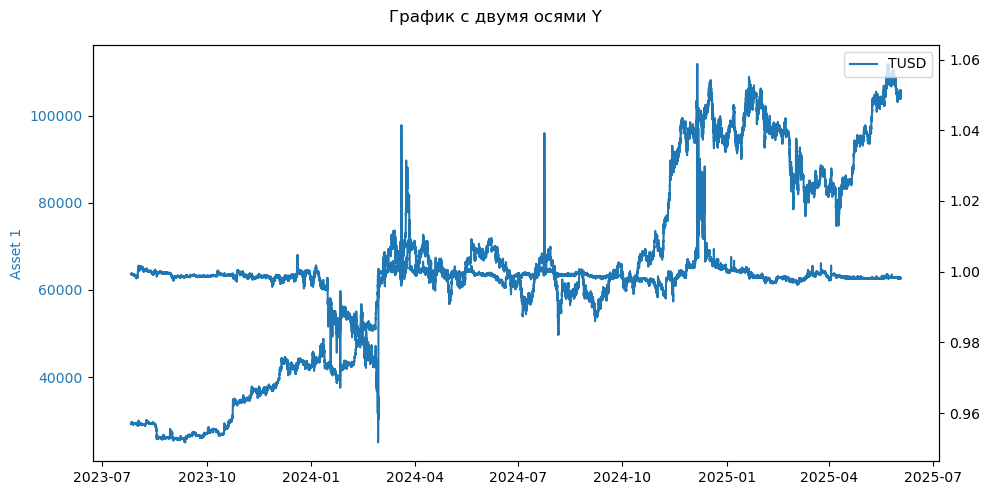

In [53]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Первая ось Y
ax1.plot(df.BTC, color='tab:blue', label='Asset 1')
ax1.set_ylabel('Asset 1', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Вторая ось Y
ax2 = ax1.twinx()
for col in df.columns.drop(['BTC', 'WBTC', 'FDUSD', 'PAXG']):
    if col != 'BTC':
        ax2.plot(df[col], label=col)  # можно добавить color по желанию
# Общий заголовок и легенда
fig.suptitle('График с двумя осями Y')
fig.tight_layout()
plt.legend()
plt.show()

In [ ]:
response = requests.get("https://api.binance.com/api/v3/exchangeInfo")
usdt_pairs = [s['symbol'] for s in response.json()['symbols'] 
             if s['symbol'].endswith('USDT')]
print("All USDT pairs:", sorted(usdt_pairs))

All USDT pairs: ['1000CATUSDT', '1000CHEEMSUSDT', '1000SATSUSDT', '1INCHDOWNUSDT', '1INCHUPUSDT', '1INCHUSDT', '1MBABYDOGEUSDT', 'AAVEDOWNUSDT', 'AAVEUPUSDT', 'AAVEUSDT', 'ACAUSDT', 'ACEUSDT', 'ACHUSDT', 'ACMUSDT', 'ACTUSDT', 'ACXUSDT', 'ADADOWNUSDT', 'ADAUPUSDT', 'ADAUSDT', 'ADXUSDT', 'AERGOUSDT', 'AEURUSDT', 'AEVOUSDT', 'AGIXUSDT', 'AGLDUSDT', 'AIONUSDT', 'AIUSDT', 'AIXBTUSDT', 'AKROUSDT', 'ALCXUSDT', 'ALGOUSDT', 'ALICEUSDT', 'ALPACAUSDT', 'ALPHAUSDT', 'ALPINEUSDT', 'ALTUSDT', 'AMBUSDT', 'AMPUSDT', 'ANCUSDT', 'ANIMEUSDT', 'ANKRUSDT', 'ANTUSDT', 'ANYUSDT', 'APEUSDT', 'API3USDT', 'APTUSDT', 'ARBUSDT', 'ARDRUSDT', 'ARKMUSDT', 'ARKUSDT', 'ARPAUSDT', 'ARUSDT', 'ASRUSDT', 'ASTRUSDT', 'ASTUSDT', 'ATAUSDT', 'ATMUSDT', 'ATOMUSDT', 'AUCTIONUSDT', 'AUDIOUSDT', 'AUDUSDT', 'AUSDT', 'AUTOUSDT', 'AVAUSDT', 'AVAXUSDT', 'AWEUSDT', 'AXLUSDT', 'AXSUSDT', 'BABYUSDT', 'BADGERUSDT', 'BAKEUSDT', 'BALUSDT', 'BANANAS31USDT', 'BANANAUSDT', 'BANDUSDT', 'BARUSDT', 'BATUSDT', 'BBUSDT', 'BCCUSDT', 'BCHABCUSDT', '

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# Период анализа
start_date = "2022-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')
interval='1h'
# Тикеры
assets = {
    # "SP500": "^GSPC",
    # "NASDAQ100": "^NDX",
    # "DOWJONES": "^DJI",
    # "GOLD": "GC=F",
    # "OIL": "CL=F",
    # "USD_INDEX": "DX-Y.NYB",
    # "BTC": "BTC-USD",
    "PAXG": "PAXG-USD",
    "LUSD": "LUSD-USD",
    "RAI": "RAI-USD",
    "FRAX": "FRAX-USD"
}

def get_yahoo_data(data: assets, interval = '1d') -> pd.DataFrame:
    """
        Получает данные с Yahoo Finance по заданной частоте.
    """
    start_map = {
        '5m':   date.today() - relativedelta(days=59),
        '60m':  date.today() - relativedelta(days=729), 
        '1h':   date.today() - relativedelta(days=729),
    }

    end_map = {
        '5m':   date.today(),
        '60m':  date.today(), 
        '1h':   date.today(),
    }

    data = yf.download(
                tickers=list(data.keys()), 
                start=start_map.get(interval, start_date), 
                end=end_map.get(interval, end_date), 
                interval=interval, ignore_tz=True
            )
    data.columns = [f"{data[t]}_{c}" for c, t in data.columns]

    return data.ffill()

df = get_yahoo_data()
# # Объединение и расчёт доходностей
# combined = pd.DataFrame(data)
# returns = combined.pct_change().dropna()

# # Расчёт корреляций
# pearson_corr = returns.corr(method='pearson')
# spearman_corr = returns.corr(method='spearman')

# # Вывод
# print("📊 Pearson Correlation Matrix:")
# print(pearson_corr.round(3))

# print("\n📊 Spearman Correlation Matrix:")
# print(spearman_corr.round(3))


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PAXG-USD,PAXG-USD,PAXG-USD,PAXG-USD,PAXG-USD
Datetime,,,,,
2023-06-02 00:00:00+00:00,1980.48,1981.21,1979.79,1981.21,0
2023-06-02 01:00:00+00:00,1981.26,1981.77,1980.17,1980.99,0
2023-06-02 02:00:00+00:00,1983.96,1984.95,1980.34,1980.34,0
2023-06-02 03:00:00+00:00,1985.42,1985.58,1983.39,1983.76,0
2023-06-02 04:00:00+00:00,1984.92,1986.42,1984.88,1985.81,0
...,...,...,...,...,...
2025-05-30 19:00:00+00:00,3304.88,3305.86,3304.40,3305.22,0
2025-05-30 20:00:00+00:00,3304.88,3305.65,3303.07,3305.10,622096


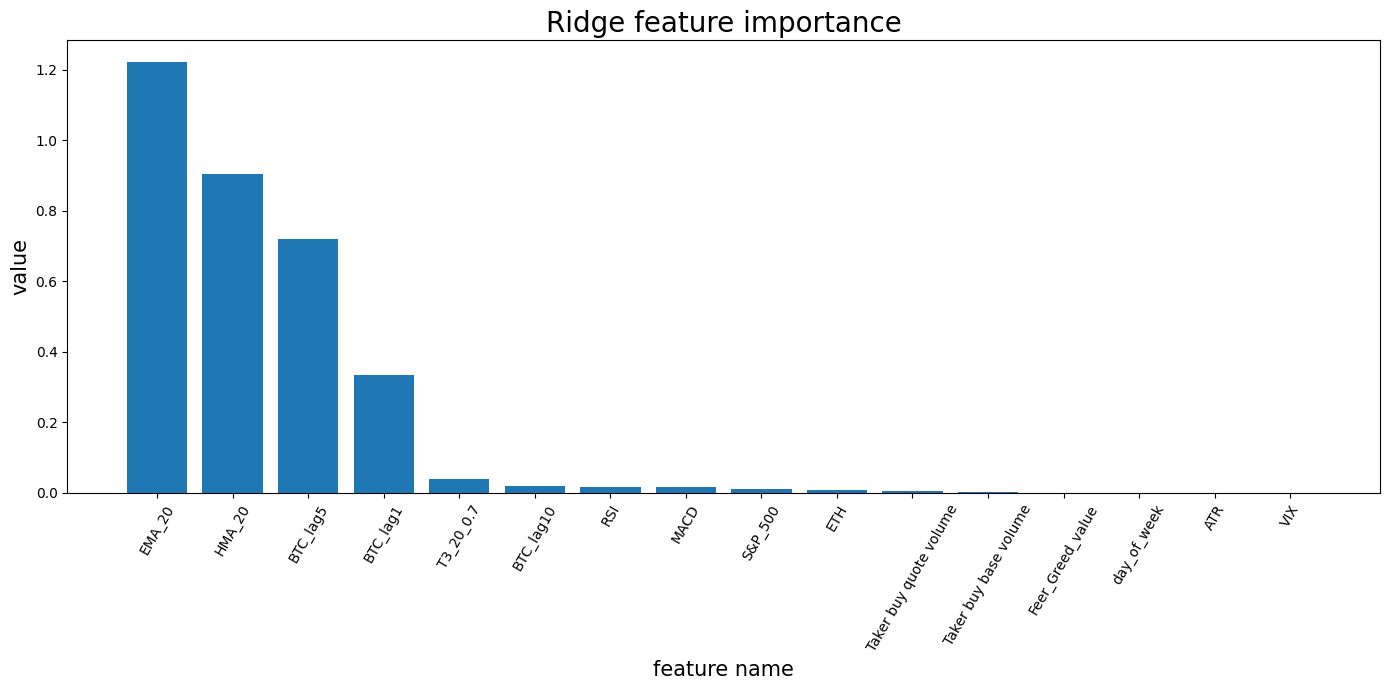

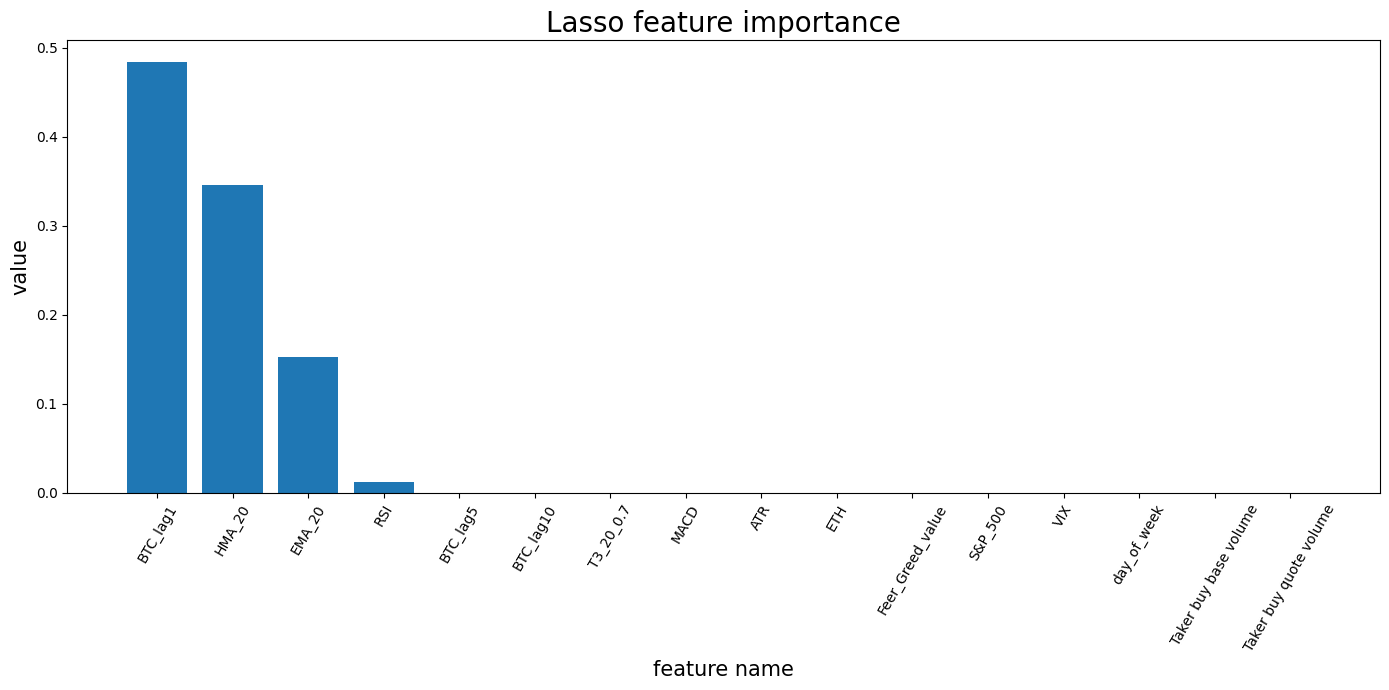

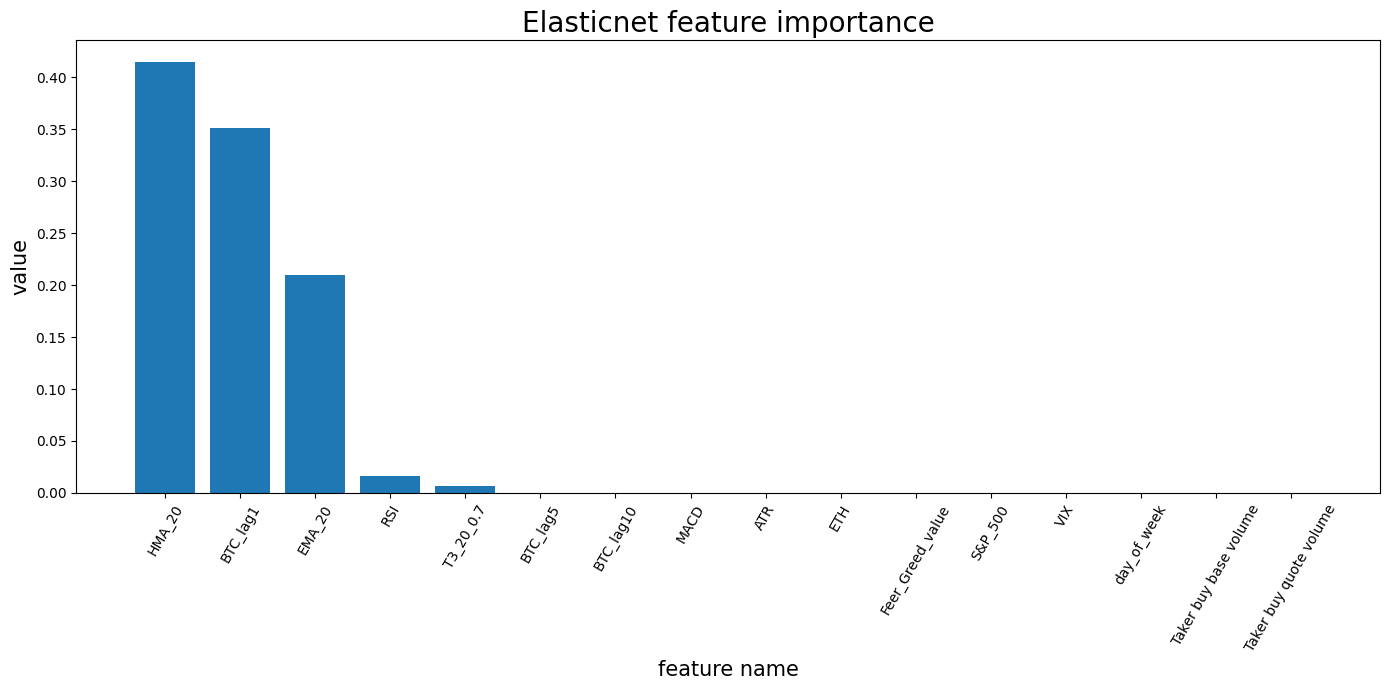

In [ ]:
def get_feature_importance(model, X: pd.DataFrame, top_n: int=None, make_plot: bool=True):
    """
    
    """
    feature_names = X.columns.tolist()

    lin_feature_importance = pd.DataFrame({
                                    'feature_names': feature_names,
                                    'feature_importance': np.abs(model.model_.best_estimator_.regressor_.named_steps['reg'].coef_)
                                }).sort_values(
                                    by='feature_importance', 
                                    ascending=False, 
                                    ignore_index=True
                                )
    
    if top_n is not None:
        lin_feature_importance = lin_feature_importance.head(top_n)
    
    if make_plot:

        plt.figure(figsize=(14, 7))
        plt.bar(
            x=lin_feature_importance['feature_names'], 
            height=lin_feature_importance['feature_importance']
        )

        plt.title(f'{model.model_type.capitalize()} feature importance', fontsize=20)
        plt.ylabel('value', fontsize=15)
        plt.xlabel('feature name', fontsize=15)

        plt.xticks(rotation=60)
        
        plt.show();

    return lin_feature_importance

ridge_feature_importance = get_feature_importance(model=ridge_day, X=X_day)
lasso_feature_importance = get_feature_importance(model=lasso_day, X=X_day)
elastic_feature_importance = get_feature_importance(model=elastic_day, X=X_day)

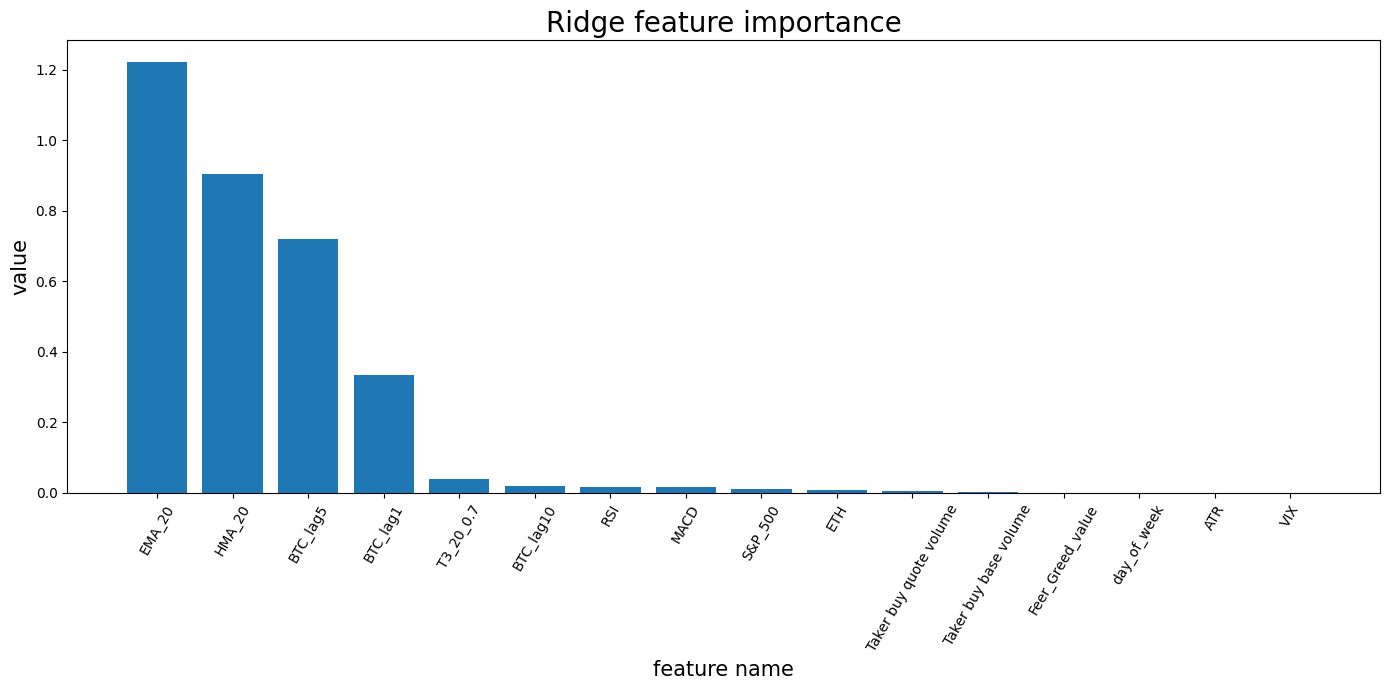

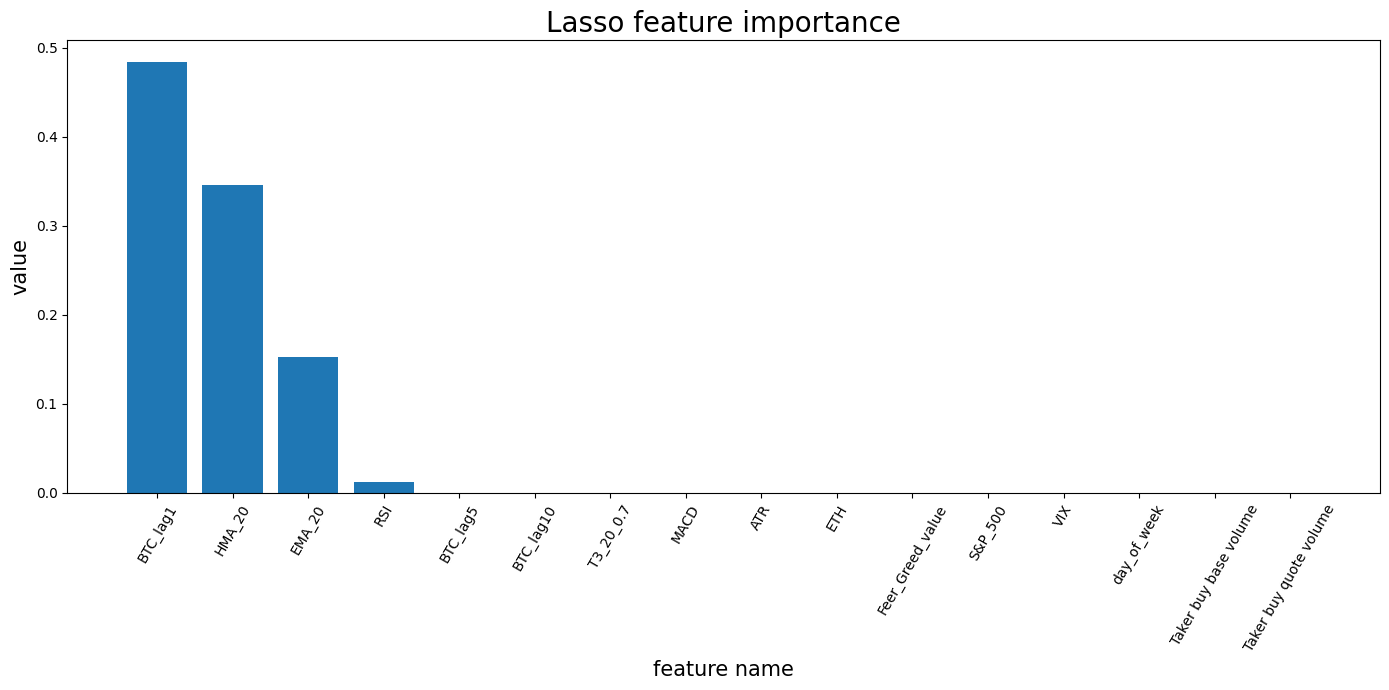

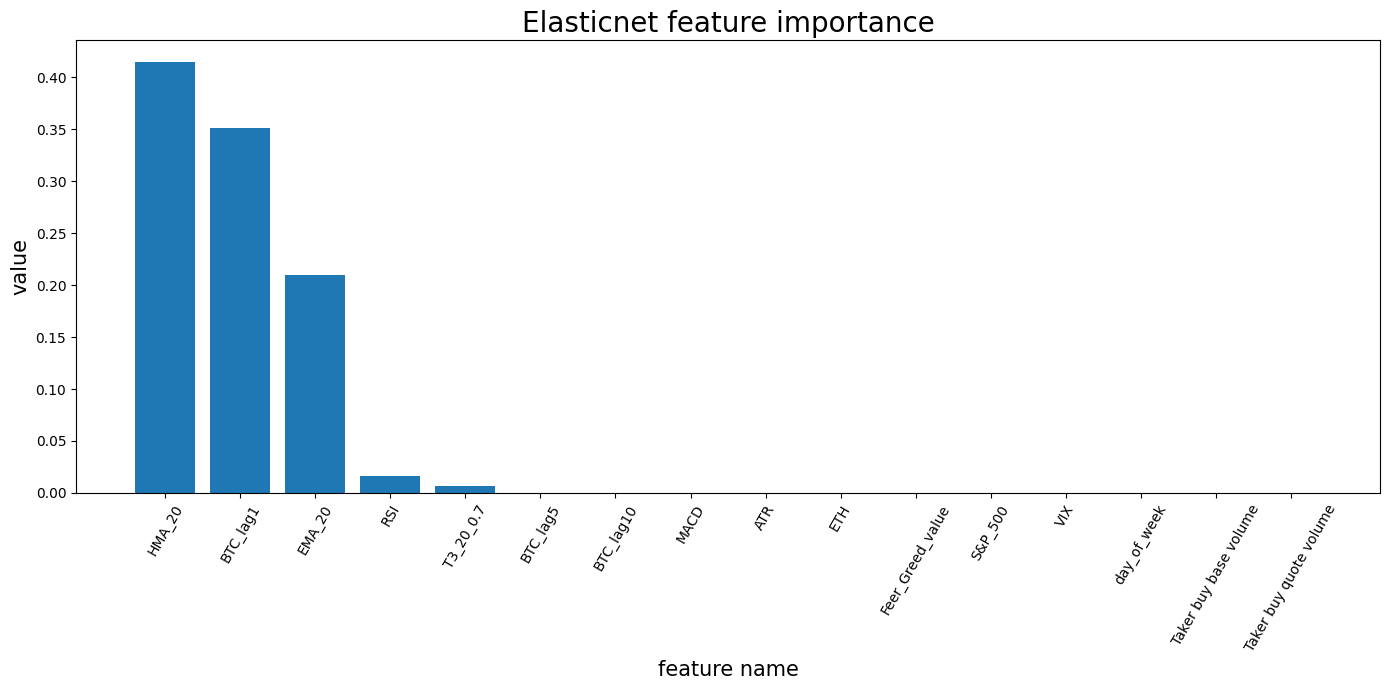

In [ ]:
def get_feature_importance(model, X: pd.DataFrame, top_n: int=None, make_plot: bool=True):
    """
    
    """
    feature_names = X.columns.tolist()

    lin_feature_importance = pd.DataFrame({
                                    'feature_names': feature_names,
                                    'feature_importance': np.abs(model.model_.best_estimator_.regressor_.named_steps['reg'].coef_)
                                }).sort_values(
                                    by='feature_importance', 
                                    ascending=False, 
                                    ignore_index=True
                                )
    
    if top_n is not None:
        lin_feature_importance = lin_feature_importance.head(top_n)
    
    if make_plot:

        plt.figure(figsize=(14, 7))
        plt.bar(
            x=lin_feature_importance['feature_names'], 
            height=lin_feature_importance['feature_importance']
        )

        plt.title(f'{model.model_type.capitalize()} feature importance', fontsize=20)
        plt.ylabel('value', fontsize=15)
        plt.xlabel('feature name', fontsize=15)

        plt.xticks(rotation=60)
        
        plt.show();

    return lin_feature_importance

ridge_feature_importance = get_feature_importance(model=ridge_day, X=X_day)
lasso_feature_importance = get_feature_importance(model=lasso_day, X=X_day)
elastic_feature_importance = get_feature_importance(model=elastic_day, X=X_day)

In [ ]:
# import os
# import requests
# import pandas as pd
# from datetime import datetime

# # Получение API-ключа CoinGecko из переменных окружения (для Pro-плана)
# API_KEY = os.getenv("CG-eEdFDSqcvJ4bFw8XB3t1SAre")
# # Выбор базового URL: Pro-API при наличии ключа, публичный API иначе
# BASE_URL = "https://pro-api.coingecko.com/api/v3" if API_KEY else "https://api.coingecko.com/api/v3"

# headers = {"Accept": "application/json"}
# if API_KEY:
#     headers["x-cg-pro-api-key"] = API_KEY


# def get_market_chart_range(coin_id: str, vs_currency: str, from_date: str, to_date: str) -> dict:
#     """
#     Запрашивает исторические данные по монете в указанном диапазоне дат.
#     from_date, to_date в формате YYYY-MM-DD.
#     Возвращает JSON с полями prices, market_caps, total_volumes.
#     """
#     from_ts = int(datetime.strptime(from_date, "%Y-%m-%d").timestamp())
#     to_ts = int(datetime.strptime(to_date, "%Y-%m-%d").timestamp())
#     url = f"{BASE_URL}/coins/{coin_id}/market_chart/range"
#     params = {"vs_currency": vs_currency, "from": from_ts, "to": to_ts}
#     response = requests.get(url, params=params, headers=headers)
#     try:
#         response.raise_for_status()
#     except requests.HTTPError as e:
#         print(f"Ошибка при запросе {url}: {response.status_code} - {response.text}")
#         raise
#     return response.json()


# def fetch_bitcoin_historical(start_date: str, end_date: str) -> pd.DataFrame:
#     """
#     Возвращает DataFrame с историческими данными Bitcoin:
#     datetime, price (USD), market_cap (USD), circulating_supply.
#     """
#     data = get_market_chart_range("bitcoin", "usd", start_date, end_date)
#     df_mc = pd.DataFrame(data["market_caps"], columns=["timestamp", "market_cap"])
#     df_price = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
#     df = df_mc.copy()
#     df["price"] = df_price["price"]
#     df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
#     df["circulating_supply"] = df["market_cap"] / df["price"]
#     return df[["datetime", "price", "market_cap", "circulating_supply"]]


# def fetch_global_historical(days: str = "max") -> pd.DataFrame:
#     """
#     Возвращает DataFrame с историческими данными общей капитализации рынка.
#     Требует Pro-плана CoinGecko для эндпоинта /global/market_cap_chart.
#     Параметр days поддерживает '1', '30', 'max' и др.
#     """
#     url = f"{BASE_URL}/global/market_cap_chart"
#     params = {"vs_currency": "usd", "days": days}
#     response = requests.get(url, params=params, headers=headers)
#     try:
#         response.raise_for_status()
#     except requests.HTTPError as e:
#         print(f"Ошибка при запросе {url}: {response.status_code} - {response.text}")
#         raise
#     data = response.json()
#     df = pd.DataFrame(data.get("market_cap", []), columns=["timestamp", "global_market_cap"])
#     df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
#     return df[["datetime", "global_market_cap"]]


# # if __name__ == "__main__":
# START_DATE = "2025-01-01"  # Дата первого блока Bitcoin
# # END_DATE = datetime.utcnow().strftime("%Y-%m-%d")
# END_DATE = "2025-01-07"

# # Сбор данных Bitcoin
# btc_df = fetch_bitcoin_historical(START_DATE, END_DATE)
# # Сбор глобальных данных рынка
# global_df = fetch_global_historical()

# # Объединение и расчет Bitcoin Dominance
# merged = pd.merge(btc_df, global_df, on="datetime", how="inner")
# merged["dominance"] = merged["market_cap"] / merged["global_market_cap"] * 100

In [ ]:
df_eth = pd.read_csv('eth_info.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'eth_info.csv'

In [ ]:
eth = df_eth.copy()
eth['price'] = (eth.close * 2 + eth.low + eth.high) / 4

eth

,open,high,low,close,volume,Target,price
0,1602.64,1612.00,1602.40,1611.51,12701.10,1.00,1609.36
1,1611.45,1614.68,1610.44,1614.26,5146.27,1.00,1613.41
2,1614.17,1614.49,1610.15,1610.87,4826.25,1.00,1611.59
3,1610.88,1618.17,1610.88,1613.13,6040.55,1.00,1613.83
4,1613.05,1616.92,1612.06,1615.67,3523.77,1.00,1615.08
...,...,...,...,...,...,...,...
1794864,3177.55,3185.00,3175.13,3185.00,6688.13,0.00,3182.53
1794865,3184.99,3185.70,3180.12,3185.61,2462.04,0.00,3184.26
1794866,3185.60,3192.84,3183.38,3192.14,4078.28,0.00,3190.12
1794867,3192.13,3193.58,3188.62,3189.30,2870.37,0.00,3190.20


In [ ]:
timestamp_ms = 1614787200000

# Переводим в секунды и создаём datetime в UTC
dt_utc = datetime.fromtimestamp(timestamp_ms / 1000, tz=timezone.utc)

eth.index = pd.date_range(
    start=dt_utc,
    periods=1_794_869,
    freq='T',         # 'T' == минута
    tz=None
)

eth.columns = [
    name.capitalize() for name in eth.columns 
]

In [ ]:
# # api yahoo finance стало работать с переменным успехом, из-за чего была необходимость в доп. ф-ии

# def fetch_all_binance_btc(
#         start_date="2018-01-01", 
#         end_date=None, 
#         interval: str='1d'
# ):
#     """
#     собирает данные с официального api биржи Binance
#     способна собирать информацию по большинству активов. используем для сбора данных по BTC

#     `start_date`: str, начальная дата
#     `end_date`: str, последняя дата
#     `interval`: str, частота данных ('1h', '1d', '1w') 
#     """
#     if end_date is None:
#         end_date = datetime.now().strftime("%Y-%m-%d")
    
#     start_timestamp = int(pd.Timestamp(start_date).timestamp() * 1000)
#     end_timestamp = int(pd.Timestamp(end_date).timestamp() * 1000)

#     url = "https://api.binance.com/api/v3/klines"
#     all_data = []

#     while start_timestamp < end_timestamp:
        
#         time.sleep(3)

#         params = {
#             "symbol": "BTCUSDT",
#             "interval": interval,
#             "startTime": start_timestamp,
#             "endTime": end_timestamp,
#             "limit": 1000  
#         }

#         response = requests.get(url, params=params)
#         data = response.json()

#         if not data:
#             break  

#         all_data.extend(data)

#         last_candle_time = data[-1][0]
#         start_timestamp = last_candle_time + 1

#         last_date = pd.to_datetime(last_candle_time, unit="ms").strftime("%Y-%m-%d")
#         print(f"Fetched data up to {last_date}")

#     columns = [
#         "Open time",
#         "Open",
#         "High",
#         "Low",
#         "Close",
#         "Volume",
#         "Close time",
#         "Quote asset volume",
#         "Number of trades",
#         "Taker buy base volume",
#         "Taker buy quote volume",
#         "Ignore"
#     ]
#     df = pd.DataFrame(all_data, columns=columns)

#     df["Date"] = pd.to_datetime(df["Open time"], unit="ms")
 
#     numeric_cols = columns
#     df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

#     df = df.drop_duplicates(subset=["Date"]).sort_values("Date")

#     return df

# btc = fetch_all_binance_btc(eth.index.min(), eth.index.max(), '1m')

# btc.to_csv('btc_info.csv')

In [ ]:
# # api yahoo finance стало работать с переменным успехом, из-за чего была необходимость в доп. ф-ии

# def fetch_all_binance_btc(
#         start_date="2018-01-01", 
#         end_date=None, 
#         interval: str='1d',
#         symbol: str='ETHUSDT'
# ):
#     """
#     собирает данные с официального api биржи Binance
#     способна собирать информацию по большинству активов. используем для сбора данных по BTC

#     `start_date`: str, начальная дата
#     `end_date`: str, последняя дата
#     `interval`: str, частота данных ('1h', '1d', '1w') 
#     """
#     if end_date is None:
#         end_date = datetime.now().strftime("%Y-%m-%d")
    
#     start_timestamp = int(pd.Timestamp(start_date).timestamp() * 1000)
#     end_timestamp = int(pd.Timestamp(end_date).timestamp() * 1000)

#     url = "https://api.binance.com/api/v3/klines"
#     all_data = []

#     while start_timestamp < end_timestamp:
        
#         time.sleep(1)

#         params = {
#             "symbol": symbol,
#             "interval": interval,
#             "startTime": start_timestamp,
#             "endTime": end_timestamp,
#             "limit": 1000  
#         }

#         response = requests.get(url, params=params)
#         data = response.json()

#         if not data:
#             break  

#         all_data.extend(data)

#         last_candle_time = data[-1][0]
#         start_timestamp = last_candle_time + 1

#         last_date = pd.to_datetime(last_candle_time, unit="ms").strftime("%Y-%m-%d")
#         print(f"Fetched data up to {last_date}")

#     columns = [
#         "Open time",
#         "Open",
#         "High",
#         "Low",
#         "Close",
#         "Volume",
#         "Close time",
#         "Quote asset volume",
#         "Number of trades",
#         "Taker buy base volume",
#         "Taker buy quote volume",
#         "Ignore"
#     ]
#     df = pd.DataFrame(all_data, columns=columns)

#     df["Date"] = pd.to_datetime(df["Open time"], unit="ms")
 
#     numeric_cols = columns
#     df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

#     df = df.drop_duplicates(subset=["Date"]).sort_values("Date")

#     return df

# eth_new = fetch_all_binance_btc(eth.index.min(), eth.index.max(), '1m')

# eth_new.to_csv('eth_new_info.csv')

In [ ]:
eth_vols = pd.read_csv('eth_new_info.csv', index_col=['Date'], parse_dates=['Date'])[
    ['Volume', 'Quote asset volume', 'Number of trades', 'Taker buy base volume', 'Taker buy quote volume']
]
eth_vols.index  = eth_vols.index.tz_localize(None)
eth.index       = eth.index.tz_localize(None)

eth = eth.drop(columns=['Volume']).merge(left_index=True, right_index=True, right=eth_vols)
eth.columns = [
    name.replace(' ', '_') + '_ETH' for name in eth.columns
]

In [ ]:
btc = pd.read_csv('btc_info.csv', index_col=['Date'], parse_dates=['Date']).loc[:, ['Open', 'High', 'Low', 'Close', 'Volume', 'Quote asset volume', 
                                                                                    'Number of trades', 'Taker buy base volume', 'Taker buy quote volume']]

btc.index = btc.index.tz_localize(None)
btc['BTC_price'] = (2 * btc['Close'] + btc['Low'] + btc['High']) / 4
btc.columns = [
    name.replace(' ', '_') + "_BTC"  for name in btc.columns
]
btc.rename(columns={
    'BTC_price_BTC': 'Price_BTC'
}, inplace=True)

# BTC returns и волатильности
for lag in [1, 5, 10]:
    btc[f'Return_BTC_{lag}m']   = btc['Close_BTC'].pct_change(lag)
btc['Volatility_BTC_5m'] = btc['Close_BTC'].pct_change().rolling(5).std()

btc

,Open_BTC,High_BTC,Low_BTC,Close_BTC,Volume_BTC,Quote_asset_volume_BTC,Number_of_trades_BTC,Taker_buy_base_volume_BTC,Taker_buy_quote_volume_BTC,Price_BTC,Return_BTC_1m,Return_BTC_5m,Return_BTC_10m,Volatility_BTC_5m
Date,,,,,,,,,,,,,,
2021-03-03 16:25:00,51275.40,51357.14,51250.00,51350.73,135.41,6949205.40,3965,65.20,3345849.63,51327.15,NaN,NaN,NaN,NaN
2021-03-03 16:26:00,51354.26,51444.89,51331.55,51415.67,145.43,7473079.96,3425,96.22,4944712.65,51401.95,0.00,NaN,NaN,NaN
2021-03-03 16:27:00,51420.32,51442.43,51353.20,51402.58,130.74,6719806.02,3559,73.38,3771741.58,51400.20,-0.00,NaN,NaN,NaN
2021-03-03 16:28:00,51400.70,51423.32,51337.48,51394.30,77.00,3956320.01,2617,31.67,1627494.34,51387.35,-0.00,NaN,NaN,NaN
2021-03-03 16:29:00,51394.30,51434.32,51384.00,51425.96,105.39,5417401.86,2984,73.43,3774596.80,51417.56,0.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01 02:24:00,63904.00,64008.01,63900.00,64008.01,39.89,2549992.97,1956,25.73,1645512.98,63981.01,0.00,-0.00,-0.00,0.00
2024-08-01 02:25:00,64008.01,64008.01,63938.00,63984.00,16.14,1032598.46,1439,10.02,641113.11,63978.50,-0.00,-0.00,-0.00,0.00
2024-08-01 02:26:00,63984.00,64090.90,63966.00,64090.90,13.64,872979.99,1358,7.40,473595.17,64059.67,0.00,0.00,-0.00,0.00


In [ ]:
# EMA
eth['EMA_3']  = ta.ema(eth['Close_ETH'], length=3)
eth['EMA_8']  = ta.ema(eth['Close_ETH'], length=8)
eth['EMA_21'] = ta.ema(eth['Close_ETH'], length=21)

# DEMA и TEMA
eth['DEMA_5']  = ta.dema(eth['Close_ETH'], length=5)
eth['TEMA_13'] = ta.tema(eth['Close_ETH'], length=13)

# HMA
eth['HMA_8'] = ta.hma(eth['Close_ETH'], length=8)

# KAMA (ER window=8, fast=2, slow=30)
eth['KAMA_8_2_30'] = ta.kama(eth['Close_ETH'], length=8, pow1=2, pow2=30)

# VWMA (объёмно-взвешенная SMA) для 5 и 15 минут
eth['VWMA_5']  = ta.vwma(eth['Close_ETH'], eth['Volume_ETH'], length=5)
eth['VWMA_15'] = ta.vwma(eth['Close_ETH'], eth['Volume_ETH'], length=15)


# === 2. Лаги доходностей и rolling-статистики ===

# доходности и лог-доходности
for lag in [1, 2, 3, 5, 10]:
    eth[f'Return_{lag}m']     = eth['Close_ETH'].pct_change(lag)
    eth[f'Logret_{lag}m']     = (eth['Close_ETH'] / eth['Close_ETH'].shift(lag)).apply(np.log)

# rolling-std и rolling-mean доходностей
for window in [5, 10, 15]:
    eth[f'Return_std_{window}m']  = eth['Return_1m'].rolling(window).std()
    eth[f'Return_mean_{window}m'] = eth['Return_1m'].rolling(window).mean()

# trade flow imbalance (берём taker-buy vs taker-sell)
eth['Taker_sell_base_ETH'] = eth['Volume_ETH'] - eth['Taker_buy_base_volume_ETH']
eth['trade_imbalance_ETH'] = (
    eth['Taker_buy_base_volume_ETH'] - eth['Taker_sell_base_ETH']
) / eth['Volume_ETH']

# число сделок и средний размер сделки
eth['Avg_trade_size'] = eth['Volume_ETH'] / eth['Number_of_trades_ETH']

In [ ]:
df = eth.merge(
    btc, left_index=True, right_index=True
)

# rolling-корреляция ETH vs BTC
# сначала считайте minute-return для BTC
df['Return_BTC_1m'] = df['Close_BTC'].pct_change(1)
for window in [5, 15]:
    df[f'Corr_ETH_BTC_{window}m'] = (
        df['Return_1m']
        .rolling(window)
        .corr(df['Return_BTC_1m'])
    )

In [ ]:
sample = df[['Target_ETH', 'Close_ETH']]
sample['shift_ETH'] = sample.Close_ETH.shift(300)
sample['proc_change'] = (sample['Close_ETH'] - sample['shift_ETH']) * 100 / sample['Close_ETH']

sample.iloc[300:]

,Target_ETH,Close_ETH,shift_ETH,proc_change
2021-03-03 21:25:00,1.00,1585.10,1615.36,-1.91
2021-03-03 21:26:00,1.00,1583.01,1616.47,-2.11
2021-03-03 21:27:00,1.00,1585.31,1615.10,-1.88
2021-03-03 21:28:00,1.00,1587.80,1616.16,-1.79
2021-03-03 21:29:00,1.00,1590.90,1618.61,-1.74
...,...,...,...,...
2024-08-01 02:24:00,0.00,3185.00,3241.02,-1.76
2024-08-01 02:25:00,0.00,3185.61,3236.39,-1.59
2024-08-01 02:26:00,0.00,3192.14,3233.87,-1.31
2024-08-01 02:27:00,0.00,3189.30,3233.32,-1.38


In [ ]:
def set_global_seed(seed: int):
    """Фиксируем сиды для воспроизводимости"""
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)


class CryptoHyperModelClassifier(kt.HyperModel):
    def __init__(self, window_size: int, exog_dim: int, fixed_arch: str = None):
        self.window_size = window_size
        self.exog_dim = exog_dim
        self.fixed_arch = fixed_arch

    def build(self, hp):
        arch = self.fixed_arch or hp.Choice('architecture', ['MLP', 'LSTM', 'StackedLSTM', 'CNN_LSTM', 'GRU'])
        inp_seq = Input(shape=(self.window_size, 1), name='seq_input')
        inp_ex = Input(shape=(self.exog_dim,), name='exog_input')

        # последовательная часть
        if arch == 'MLP':
            x = Flatten()(inp_seq)
            for i in range(hp.Int('mlp_layers', 1, 3)):
                x = Dense(hp.Int(f'mlp_units_{i}', 32, 128, 32), activation='relu')(x)
                x = Dropout(hp.Float(f'mlp_drop_{i}', 0.1, 0.5, 0.1))(x)
                x = BatchNormalization()(x)

        elif arch == 'LSTM':
            x = LSTM(hp.Int('lstm_units', 32, 128, 32))(inp_seq)
            x = Dropout(hp.Float('lstm_drop', 0.1, 0.5, 0.1))(x)

        elif arch == 'StackedLSTM':
            x = inp_seq
            for i in range(hp.Int('stacked_layers', 2, 3)):
                return_seq = i < hp.get('stacked_layers') - 1
                x = LSTM(hp.Int(f'stack_units_{i}', 32, 128, 32), return_sequences=return_seq)(x)
                x = Dropout(hp.Float(f'stack_drop_{i}', 0.1, 0.5, 0.1))(x)

        elif arch == 'CNN_LSTM':
            x = Conv1D(
                filters=hp.Int('cnn_filters', 16, 64, 16), 
                kernel_size=hp.Int('cnn_kernel', 2, 5), 
                activation='relu'
            )(inp_seq)
            x = MaxPooling1D(pool_size=hp.Int('pool_size', 2, 4))(x)
            x = Dropout(hp.Float('cnn_drop', 0.1, 0.5, 0.1))(x)
            x = LSTM(hp.Int('cnn_lstm_units', 32, 128, 32))(x)

        else:  # GRU
            x = GRU(hp.Int('gru_units', 32, 128, 32))(inp_seq)
            x = Dropout(hp.Float('gru_drop', 0.1, 0.5, 0.1))(x)

        # экзогенные признаки
        y_ex = inp_ex
        for i in range(hp.Int('ex_layers', 1, 2)):
            y_ex = Dense(hp.Int(f'ex_units_{i}', 16, 64, 16), activation='relu')(y_ex)
            y_ex = Dropout(hp.Float(f'ex_drop_{i}', 0.1, 0.5, 0.1))(y_ex)

        merged = concatenate([x, y_ex])
        out = Dense(1, activation='sigmoid', name='output')(merged)

        model = Model([inp_seq, inp_ex], out)
        model.compile(
            optimizer=optimizers.Adam(hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )
        return model


class NeuralClassifier:
    def __init__(self,
                 window_size=60,
                 test_size=40000,
                 min_gap=2000,
                 cycles=20,
                 max_trials=10,
                 epochs=50,
                 batch_size=32,
                 seed=42):
        self.window_size = window_size
        self.test_size = test_size
        self.min_gap = min_gap
        self.cycles = cycles
        self.max_trials = max_trials
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        set_global_seed(self.seed)
        self.results_ = []

    def _generate_splits(self, N):
        starts = np.linspace(self.window_size,
                             N - self.min_gap - self.test_size,
                             self.cycles, dtype=int)
        for tr_end in starts:
            te_start = tr_end + self.min_gap
            yield (0, tr_end), (te_start, te_start + self.test_size)

    def fit(self, df: pd.DataFrame, target_col: str):
        y = df[target_col].values
        exog = df.drop([target_col], axis=1).values

        # Формируем окна
        X_seq, X_ex, y_seq = [], [], []
        for i in range(len(y) - self.window_size):
            X_seq.append(y[i:i + self.window_size].reshape(self.window_size, 1))
            X_ex.append(exog[i + self.window_size])
            y_seq.append(y[i + self.window_size])
        X_seq = np.array(X_seq)
        X_ex = np.array(X_ex)
        y_seq = np.array(y_seq)

        N = len(y_seq)
        for (tr0, tr1), (te0, te1) in self._generate_splits(N):
            X_seq_tr, X_ex_tr, y_tr = X_seq[tr0:tr1], X_ex[tr0:tr1], y_seq[tr0:tr1]
            X_seq_te, X_ex_te, y_te = X_seq[te0:te1], X_ex[te0:te1], y_seq[te0:te1]

            # Масштабирование экзогенных признаков
            scaler_ex = RobustScaler().fit(X_ex_tr)
            X_ex_tr_s = scaler_ex.transform(X_ex_tr)
            X_ex_te_s = scaler_ex.transform(X_ex_te)

            # Тюнинг модели
            project_name = f'classifier_cycle_{tr1}'
            dirpath = 'keras_tuner_cls'
            path = os.path.join(dirpath, project_name)
            if os.path.exists(path): shutil.rmtree(path)
            tuner = kt.Hyperband(
                CryptoHyperModelClassifier(self.window_size, X_ex.shape[1], fixed_arch=None),
                objective='val_auc',
                max_epochs=self.epochs,
                seed=self.seed,
                directory=dirpath,
                project_name=project_name
            )
            es = callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)
            tuner.search(
                [X_seq_tr, X_ex_tr_s], y_tr,
                validation_split=0.2,
                epochs=self.epochs,
                batch_size=self.batch_size,
                callbacks=[es]
            )
            model = tuner.get_best_models(num_models=1)[0]

            # Предсказания вероятностей
            probs = model.predict([X_seq_te, X_ex_te_s]).flatten()

            # Фильтрация по порогу уверенности
            threshold = 0.8
            mask = (probs >= threshold) | (probs <= 1 - threshold)
            if mask.sum() < 0.03 * len(probs):
                threshold = 0.6
                mask = (probs >= threshold) | (probs <= 1 - threshold)

            selected_idx = np.where(mask)[0]
            y_pred_sel = (probs[selected_idx] >= 0.5).astype(int)
            y_true_sel = y_te[selected_idx]
            probs_selected = probs[selected_idx]

            # ------------------------
            # Оценка Precision-Recall и ROC
            # ------------------------
            precision_vals, recall_vals, pr_thresh = precision_recall_curve(y_true_sel, probs_selected)
            avg_prec = average_precision_score(y_true_sel, probs_selected)
            fpr, tpr, roc_thresh = roc_curve(y_true_sel, probs_selected)
            roc_auc_val = auc(fpr, tpr)
            
            # Печать метрик
            print(f"Cycle {tr1}: AP={avg_prec:.4f}, ROC AUC={roc_auc_val:.4f}")

            # Построение кривых
            plt.figure()
            plt.plot(recall_vals, precision_vals, label=f'AP={avg_prec:.2f}')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title('Precision-Recall curve')
            plt.legend()
            plt.show()

            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC={roc_auc_val:.2f}')
            plt.plot([0,1], [0,1], linestyle='--')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC curve')
            plt.legend()
            plt.show()

            # Сохраняем метрики
            acc = np.mean(y_pred_sel == y_true_sel)
            self.results_.append({
                'train_range': (tr0, tr1),
                'test_range': (te0, te1),
                'n_preds': len(selected_idx),
                'accuracy': acc,
                'auc': tf.keras.metrics.AUC()(y_true_sel, probs_selected).numpy(),
                'avg_precision': avg_prec,
                'roc_auc': roc_auc_val
            })
        return pd.DataFrame(self.results_)


In [ ]:
from dateutil.relativedelta import relativedelta

dt = datetime(2025,6,30)
dt -= relativedelta(months=1)
dt = dt.replace(day=1).strftime(format='%Y-%m-%d')

dt

'2025-05-01'

In [ ]:
df = pd.read_csv('data.csv', parse_dates=['Unnamed: 0']).rename(columns={'Unnamed: 0': 'Date'}).set_index('Date')
df.loc[:, ~df.columns.isin(['Target_ETH'])] = df.loc[:, ~df.columns.isin(['Target_ETH'])].shift()
df = df.iloc[1:]

df.head()

,Open_ETH,High_ETH,Low_ETH,Close_ETH,Target_ETH,Price_ETH,Volume_ETH,Quote_asset_volume_ETH,Number_of_trades_ETH,Taker_buy_base_volume_ETH,Taker_buy_quote_volume_ETH,EMA_3,EMA_8,EMA_21,DEMA_5,TEMA_13,HMA_8,KAMA_8_2_30,VWMA_5,VWMA_15,Return_1m,Logret_1m,Return_2m,Logret_2m,Return_3m,Logret_3m,Return_5m,Logret_5m,Return_10m,Logret_10m,Return_std_5m,Return_mean_5m,Return_std_10m,Return_mean_10m,Return_std_15m,Return_mean_15m,Taker_sell_base_ETH,trade_imbalance_ETH,Avg_trade_size,Open_BTC,High_BTC,Low_BTC,Close_BTC,Volume_BTC,Quote_asset_volume_BTC,Number_of_trades_BTC,Taker_buy_base_volume_BTC,Taker_buy_quote_volume_BTC,Price_BTC,Return_BTC_1m,Return_BTC_5m,Return_BTC_10m,Volatility_BTC_5m,Corr_ETH_BTC_5m,Corr_ETH_BTC_15m
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-03-03 16:26:00,1611.69,1615.91,1609.73,1615.36,1.00,1614.09,1385.71,2230652.78,1031.00,708.07,1140282.60,1612.45,1609.85,1610.83,1613.09,1610.41,1613.37,1055.33,1610.82,1608.64,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,677.64,0.02,1.34,51275.40,51357.14,51250.00,51350.73,135.41,6949205.40,3965.00,65.20,3345849.63,51327.15,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-03 16:27:00,1615.36,1617.69,1614.64,1616.47,1.00,1616.32,1150.60,1856886.42,961.00,475.87,768170.99,1614.46,1611.32,1611.35,1615.46,1612.85,1616.37,1142.83,1613.01,1609.31,0.00,0.00,0.00,0.00,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,674.73,-0.17,1.20,51354.26,51444.89,51331.55,51415.67,145.43,7473079.96,3425.00,96.22,4944712.65,51401.95,0.00,NaN,NaN,NaN,NaN,NaN
2021-03-03 16:28:00,1616.47,1616.75,1614.43,1615.10,1.00,1615.35,598.59,965943.55,627.00,347.54,560808.15,1614.78,1612.16,1611.69,1615.87,1614.11,1617.59,1208.57,1613.98,1609.62,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,251.05,0.16,0.95,51420.32,51442.43,51353.20,51402.58,130.74,6719806.02,3559.00,73.38,3771741.58,51400.20,-0.00,NaN,NaN,NaN,NaN,NaN
2021-03-03 16:29:00,1615.18,1616.16,1614.34,1616.16,1.00,1615.70,1035.51,1671002.24,592.00,426.98,688996.37,1615.47,1613.05,1612.09,1616.55,1615.38,1617.70,1312.38,1615.35,1610.01,0.00,0.00,-0.00,-0.00,0.00,0.00,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,608.53,-0.18,1.75,51400.70,51423.32,51337.48,51394.30,77.00,3956320.01,2617.00,31.67,1627494.34,51387.35,-0.00,NaN,NaN,NaN,NaN,NaN
2021-03-03 16:30:00,1616.16,1618.88,1616.03,1618.61,1.00,1618.03,743.27,1200435.15,614.00,375.81,607042.97,1617.04,1614.29,1612.69,1618.17,1617.16,1618.21,1392.49,1616.25,1610.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,367.45,0.01,1.21,51394.30,51434.32,51384.00,51425.96,105.39,5417401.86,2984.00,73.43,3774596.80,51417.56,0.00,NaN,NaN,NaN,NaN,NaN


In [ ]:
target_prev = df.Target_ETH

df.Target_ETH_new = np.abs(df.Close_ETH.iloc[300:] - df.Close_ETH.shift(300)) / df.Close_ETH.shift(300)

In [ ]:
import os
import random
import shutil

# Ensure XLA can find CUDA libdevice bitcode
os.environ['XLA_FLAGS'] = "--xla_gpu_cuda_data_dir=/home/user/miniconda3/envs/diplom"

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Input, Model, optimizers, callbacks
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, LSTM, GRU, Conv1D, MaxPooling1D, concatenate
import keras_tuner as kt
from keras_tuner import Objective
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# GPU Configuration: dynamic memory growth and logging
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Detected {len(gpus)} GPU(s): {gpus}")

# Log placement (CPU/GPU)
tf.debugging.set_log_device_placement(False)

# Distributed strategy (single or multi-GPU)
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices in sync: {strategy.num_replicas_in_sync}")

# Reproducibility
def set_global_seed(seed: int):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

class CryptoHyperModelClassifier(kt.HyperModel):
    def __init__(self, window_size: int, exog_dim: int, fixed_arch: str = None):
        self.window_size = window_size
        self.exog_dim = exog_dim
        self.fixed_arch = fixed_arch

    def build(self, hp):
        with strategy.scope():
            arch = self.fixed_arch or hp.Choice('architecture', ['MLP','LSTM','StackedLSTM','CNN_LSTM','GRU'])
            inp_seq = Input((self.window_size,1), name='seq_input')
            inp_ex  = Input((self.exog_dim,), name='exog_input')

            # Sequence branch
            if arch=='MLP':
                x = Flatten()(inp_seq)
                for i in range(hp.Int('mlp_layers',1,3)):
                    x = Dense(hp.Int(f'mlp_units_{i}',32,128,32), activation='relu')(x)
                    x = Dropout(hp.Float(f'mlp_drop_{i}',0.1,0.5,0.1))(x)
                    x = BatchNormalization()(x)
            elif arch=='LSTM':
                x = LSTM(hp.Int('lstm_units',32,128,32))(inp_seq)
                x = Dropout(hp.Float('lstm_drop',0.1,0.5,0.1))(x)
            elif arch=='StackedLSTM':
                x = inp_seq
                nlayers = hp.Int('stacked_layers',2,3)
                for i in range(nlayers):
                    return_seq = i<nlayers-1
                    x = LSTM(hp.Int(f'stack_units_{i}',32,128,32), return_sequences=return_seq)(x)
                    x = Dropout(hp.Float(f'stack_drop_{i}',0.1,0.5,0.1))(x)
            elif arch=='CNN_LSTM':
                x = Conv1D(filters=hp.Int('cnn_filters',16,64,16), kernel_size=hp.Int('cnn_kernel',2,5), activation='relu')(inp_seq)
                x = MaxPooling1D(pool_size=hp.Int('pool_size',2,4))(x)
                x = Dropout(hp.Float('cnn_drop',0.1,0.5,0.1))(x)
                x = LSTM(hp.Int('cnn_lstm_units',32,128,32))(x)
            else:
                x = GRU(hp.Int('gru_units',32,128,32))(inp_seq)
                x = Dropout(hp.Float('gru_drop',0.1,0.5,0.1))(x)

            # Exogenous branch
            y_ex = inp_ex
            for i in range(hp.Int('ex_layers',1,2)):
                y_ex = Dense(hp.Int(f'ex_units_{i}',16,64,16), activation='relu')(y_ex)
                y_ex = Dropout(hp.Float(f'ex_drop_{i}',0.1,0.5,0.1))(y_ex)

            merged = concatenate([x,y_ex])
            out = Dense(1, activation='sigmoid')(merged)

            model = Model([inp_seq,inp_ex], out)
            model.compile(
                optimizer=optimizers.Adam(hp.Float('learning_rate',1e-4,1e-2, sampling='log')),
                loss='binary_crossentropy', metrics=['accuracy',tf.keras.metrics.AUC(name='auc')]
            )
        return model

class NeuralClassifier:
    def __init__(self, window_size=60, test_size=40000, min_gap=2000, cycles=20,
                 max_trials=10, epochs=50, batch_size=32, seed=42, fixed_arch=None):
        self.window_size=self.window_size=window_size
        self.test_size=test_size; self.min_gap=min_gap; self.cycles=cycles
        self.max_trials=max_trials; self.epochs=epochs; self.batch_size=batch_size
        self.seed=seed; set_global_seed(seed)
        self.results_=[]; self.fixed_arch=fixed_arch

    def _generate_splits(self,N):
        starts=np.linspace(self.window_size,N-self.min_gap-self.test_size,self.cycles,dtype=int)
        for tr_end in starts:
            te_start=tr_end+self.min_gap
            yield (0,tr_end),(te_start,te_start+self.test_size)

    def fit(self, df:pd.DataFrame, target_col:str):
        y=df[target_col].values; exog=df.drop(columns=[target_col]).values
        # Build sequences
        X_seq=[]; X_ex=[]; y_seq=[]
        for i in range(len(y)-self.window_size):
            X_seq.append(y[i:i+self.window_size].reshape(-1,1))
            X_ex.append(exog[i+self.window_size])
            y_seq.append(y[i+self.window_size])
        X_seq, X_ex, y_seq = map(np.array,(X_seq,X_ex,y_seq))

        for (tr0,tr1),(te0,te1) in self._generate_splits(len(y_seq)):
            X_seq_tr,X_seq_te = X_seq[tr0:tr1],X_seq[te0:te1]
            X_ex_tr,X_ex_te   = X_ex[tr0:tr1],X_ex[te0:te1]
            y_tr,y_te         = y_seq[tr0:tr1],y_seq[te0:te1]
            # Scale exogenous
            scaler=RobustScaler().fit(X_ex_tr)
            X_ex_tr_s, X_ex_te_s = scaler.transform(X_ex_tr), scaler.transform(X_ex_te)

            # Hyperband tuner
            project=f'classifier_cycle_{tr1}'; path=os.path.join('keras_tuner_cls',project)
            if os.path.exists(path): shutil.rmtree(path)
            with strategy.scope():
                tuner=kt.Hyperband(
                    CryptoHyperModelClassifier(self.window_size,X_ex.shape[1],fixed_arch=self.fixed_arch),
                    objective=Objective('val_auc','max'), max_epochs=self.epochs,
                    seed=self.seed, distribution_strategy=strategy,
                    directory='keras_tuner_cls', project_name=project, overwrite=True
                )
            es=callbacks.EarlyStopping('val_auc',patience=5,mode='max',restore_best_weights=True)
            tuner.search([X_seq_tr,X_ex_tr_s],y_tr,validation_split=0.2,
                         epochs=self.epochs,batch_size=self.batch_size,callbacks=[es])
            model=tuner.get_best_models(1)[0]
            with strategy.scope():
                probs=model.predict([X_seq_te,X_ex_te_s],batch_size=self.batch_size).flatten()

            # Optimal threshold via Youden's J
            fpr,tpr,thr=roc_curve(y_te,probs)
            j=tpr-fpr; ix=np.argmax(j); opt_thr=thr[ix]
            y_pred=(probs>=opt_thr).astype(int)
            acc=np.mean(y_pred==y_te)
            auc_metric=tf.keras.metrics.AUC(); auc_metric.update_state(y_te,probs)

            self.results_.append({
                'train_range':(tr0,tr1),'test_range':(te0,te1),
                'threshold':opt_thr,'accuracy':acc,'auc':auc_metric.result().numpy()
            })
        return pd.DataFrame(self.results_)

# Visualization
def plot_roc_pr(y_true,y_scores):
    fpr,tpr,_=roc_curve(y_true,y_scores)
    roc_auc=auc(fpr,tpr)
    plt.figure(); plt.plot(fpr,tpr,label=f'ROC AUC={roc_auc:.2f}'); plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR');plt.ylabel('TPR');plt.title('ROC Curve');plt.legend();
    precision,recall,_=precision_recall_curve(y_true,y_scores)
    pr_auc=average_precision_score(y_true,y_scores)
    plt.figure(); plt.plot(recall,precision,label=f'PR AUC={pr_auc:.2f}')
    plt.xlabel('Recall');plt.ylabel('Precision');plt.title('Precision-Recall');plt.legend();plt.show()


In [ ]:
import numpy as np
import pandas as pd
import random
import logging
from tqdm.auto import tqdm

# ANSI color codes for timestamp
TIME_COLOR = "\033[94m"  # Blue
RESET_COLOR = "\033[0m"

# Configure root logger with colored timestamp
formatter = logging.Formatter(
    fmt=f"{TIME_COLOR}%(asctime)s{RESET_COLOR} - %(name)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
handler = logging.StreamHandler()
handler.setFormatter(formatter)
root_logger = logging.getLogger()
root_logger.setLevel(logging.INFO)
# Replace any existing handlers
root_logger.handlers = [handler]
logger = logging.getLogger(__name__)

# Set seed for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    logger.debug(f"Random seed set to {seed}")

class TreeModelTrainer:
    """
    Trainer for RandomForest, LightGBM, and XGBoost classifiers with chronological train/test splits
    and Bayesian hyperparameter optimization via BayesSearchCV, with detailed logging and progress tracking.
    """
    def __init__(
        self,
        test_size: int = 40000,
        min_gap: int = 2000,
        cycles: int = 20,
        seed: int = 42,
        bayes_iter: int = 30,
        cv_splits: int = 3
    ):
        self.test_size = test_size
        self.min_gap = min_gap
        self.cycles = cycles
        self.seed = seed
        self.bayes_iter = bayes_iter
        self.cv = TimeSeriesSplit(n_splits=cv_splits)
        set_seed(seed)
        self.logger = logger.getChild(self.__class__.__name__)
        self.logger.info(
            f"Initialized TreeModelTrainer with test_size={test_size}, min_gap={min_gap}, "
            f"cycles={cycles}, cv_splits={cv_splits}, bayes_iter={bayes_iter}, seed={seed}"
        )

    def _generate_splits(self, n_samples: int):
        # Determine maximum possible end index for training
        max_tr_end = n_samples - self.min_gap - self.test_size
        # Require at least cv.n_splits + 1 samples in training
        if max_tr_end <= self.cv.n_splits:
            self.logger.warning(
                f"Not enough samples for splits: n_samples={n_samples}, "
                f"required_min={self.min_gap + self.test_size + (self.cv.n_splits + 1)}"
            )
            return  # No valid splits

        # Generate potential split points ensuring enough training samples
        raw_starts = np.linspace(
            self.cv.n_splits + 1,
            max_tr_end,
            min(self.cycles, max_tr_end - self.cv.n_splits),
            dtype=int
        )
        starts = np.unique(raw_starts)
        self.logger.info(f"Generating {len(starts)} split points from 0..{max_tr_end}")

        for tr_end in starts:
            te_start = tr_end + self.min_gap
            te_end = te_start + self.test_size
            if te_end > n_samples:
                self.logger.debug(f"Skipping split with test end {te_end} > n_samples {n_samples}")
                continue  # Skip if test window exceeds data
            yield (0, tr_end), (te_start, te_end)

    def fit(self, df: pd.DataFrame, target_col: str = 'Target') -> pd.DataFrame:
        # Validate that dataset is large enough for at least one split
        n_samples = len(df)
        min_required = self.min_gap + self.test_size + (self.cv.n_splits + 1)
        if n_samples < min_required:
            raise ValueError(
                f"Недостаточно сэмплов ({n_samples}) для min_gap={self.min_gap}, "
                f"test_size={self.test_size} и cv_splits={self.cv.n_splits}. "
                f"Требуется минимум {min_required} сэмплов."
            )

        self.logger.info(f"Starting fit on {n_samples} samples, target_col='{target_col}'")
        df_feat = df.copy()
        X = df_feat.drop(columns=[target_col]).values
        y = df_feat[target_col].values
        results = []

        # Define expanded search spaces for each model
        search_spaces = {
            'RandomForest': {
                'n_estimators': Integer(50, 500),
                'max_depth': Integer(3, 50),
                'min_samples_split': Integer(2, 20),
                'min_samples_leaf': Integer(1, 20),
                'max_features': Real(0.1, 1.0),
                'bootstrap': Categorical([True, False]),
                'criterion': Categorical(['gini', 'entropy'])
            },
            'LightGBM': {
                'num_leaves': Integer(20, 150),
                'learning_rate': Real(1e-3, 1e-1, prior='log-uniform'),
                'n_estimators': Integer(50, 500),
                'max_depth': Integer(3, 50),
                'min_child_samples': Integer(5, 100),
                'subsample': Real(0.5, 1.0),
                'colsample_bytree': Real(0.5, 1.0),
                'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
                'reg_lambda': Real(1e-9, 1.0, prior='log-uniform')
            },
            'XGBoost': {
                'max_depth': Integer(3, 50),
                'learning_rate': Real(1e-3, 1e-1, prior='log-uniform'),
                'n_estimators': Integer(50, 500),
                'subsample': Real(0.5, 1.0),
                'colsample_bytree': Real(0.5, 1.0),
                'gamma': Real(1e-9, 5.0, prior='log-uniform'),
                'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
                'reg_lambda': Real(1e-9, 1.0, prior='log-uniform')
            }
        }

        # Iterate over chronological splits with progress bar
        splits = list(self._generate_splits(n_samples))
        for i, ((tr0, tr1), (te0, te1)) in enumerate(splits, desc="Cycles", unit="cycle"), start=1):
            self.logger.info(f"Cycle {i}: train[{tr0}:{tr1}], test[{te0}:{te1}]")
            X_tr, X_te = X[tr0:tr1], X[te0:te1]
            y_tr, y_te = y[tr0:tr1], y[te0:te1]

            # Initialize base estimators
            base_models = {
                'RandomForest': RandomForestClassifier(random_state=self.seed, n_jobs=-1),
                'LightGBM': lgb.LGBMClassifier(random_state=self.seed, n_jobs=-1),
                'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                              random_state=self.seed, n_jobs=-1)
            }

            # Optimize each model
            for name, estimator in tqdm(base_models.items(), desc=f"Cycle {i} Models", unit="model"):
                self.logger.info(f"Starting BayesSearchCV for {name} (cycle {i})")
                opt = BayesSearchCV(
                    estimator,
                    search_spaces[name],
                    n_iter=self.bayes_iter,
                    cv=self.cv,
                    scoring='roc_auc',
                    random_state=self.seed,
                    n_jobs=-1
                )
                opt.fit(X_tr, y_tr)
                best = opt.best_estimator_
                self.logger.info(f"Best params for {name} (cycle {i}): {opt.best_params_}")

                proba = best.predict_proba(X_te)[:, 1]
                pred = (proba >= 0.5).astype(int)
                acc = accuracy_score(y_te, pred)
                auc = roc_auc_score(y_te, proba)
                self.logger.info(f"Metrics for {name} (cycle {i}): accuracy={acc:.4f}, auc={auc:.4f}")

                results.append({
                    'cycle': i,
                    'model': name,
                    'best_params': opt.best_params_,
                    'train_range': (tr0, tr1),
                    'test_range': (te0, te1),
                    'accuracy': acc,
                    'auc': auc
                })

        metrics_df = pd.DataFrame(results)
        self.logger.info("Training complete. Returning metrics DataFrame.")
        return metrics_df

In [ ]:
trainer = TreeModelTrainer(test_size=40000, min_gap=2000, cycles=20, seed=42,
                           bayes_iter=30, cv_splits=3)
metrics_df = trainer.fit(df, target_col='Target_ETH')


2025-05-22 19:52:11 - __main__.TreeModelTrainer - INFO - Initialized TreeModelTrainer with test_size=40000, min_gap=2000, cycles=20, cv_splits=3, bayes_iter=30, seed=42
2025-05-22 19:52:11 - __main__.TreeModelTrainer - INFO - Starting fit on 358769 samples, target_col='Target_ETH'
2025-05-22 19:52:12 - __main__.TreeModelTrainer - INFO - Generating 20 split points from 0..316769


Cycles:   0%|          | 0/20 [00:00<?, ?cycle/s]

2025-05-22 19:52:12 - __main__.TreeModelTrainer - INFO - Cycle 1: train[0:4], test[2004:42004]


Cycle 1 Models:   0%|          | 0/3 [00:00<?, ?model/s]

2025-05-22 19:52:12 - __main__.TreeModelTrainer - INFO - Starting BayesSearchCV for RandomForest (cycle 1)


ValueError: Got predict_proba of shape (1, 1), but need classifier with two classes.

In [ ]:
def get_right_price(data: pd.DataFrame, type_price: int=1) -> pd.DataFrame:
    """
        
    """

    columns = data.columns

    high_price  = columns[columns.str.contains('_High')]
    low_price   = columns[columns.str.contains('_Low')]
    quote       = columns[columns.str.contains('_Quote_volume')]
    trades      = columns[columns.str.contains('_Trades_count')]
    buy_base    = columns[columns.str.contains('_Taker_buy_base_volume')]
    vol         = columns[columns.str.contains('_Volume')]

    cols = data.copy()
    price_columns = high_price.str.replace('_High', '', regex=False)
    
    avg_trade_size = pd.DataFrame(
        data=(
            cols[quote].values / 
            cols[trades].values
        ),
        columns=high_price.str.replace('_High', '_avg_trade_size'),
        index=cols.index
    )
    buy_ratio = pd.DataFrame(
        data=(
            cols[buy_base].values / 
            cols[quote].values
        ),
        columns=high_price.str.replace('_High', '_taker_buy_ratio'), 
        index=cols.index
    )
    
    if type_price == 1:
        cols = pd.concat([
            avg_trade_size,
            buy_ratio,
            cols.drop(columns=(
                high_price.to_list() + 
                low_price.to_list() + 
                buy_base.to_list() +
                trades.to_list()  + 
                quote.to_list()  +
                vol.to_list()
            )), 
            pd.DataFrame(
                data=(
                    cols[high_price].values
                    + cols[low_price].values) / 2,
                columns=price_columns,
                index=cols.index
            )], axis=1
        )
    elif type_price == 2:
        cols = pd.concat([
            avg_trade_size,
            buy_ratio,
            cols.drop(columns=(
                high_price.to_list() + 
                low_price.to_list() + 
                buy_base.to_list() +
                trades.to_list()  + 
                quote.to_list()  +
                vol.to_list()
            )), 
            pd.DataFrame(
                data=cols[low_price].values,
                columns=price_columns,
                index=cols.index
            )], axis=1
        )
    columns = cols.columns.sort_values()

    return cols[columns]

def prepare_df(
    df: pd.DataFrame,
    symbol: str = 'FDUSD',
    price_type: str = 'Low',
    target_type: int = 1
) -> pd.DataFrame:
    """
    Добавляет в df:
    - бинарный таргет по росту таргетного столбца за 15 минут (3 бара);
    - лаги и процентные изменения;
    - все скользящие средние через pandas_ta (SMA, EMA, WMA, VWAP, SSF, ZLMA, VIDYA);
    - остальные техиндикаторы, волатильность, GARCH, кросс-ассеты, спреды, календарные признаки, PCA, z-score.
    
    symbol: тикер, по которому считаются MA/VWAP и спреды (например 'FDUSD')
    price_type: суффикс колонок для кросс-ассетов ('Low', 'Close' и т.п.)
    """
    df = df.copy()

    # таргет: выросла ли цена за 3 бара вперёд
    target_column = symbol
    target_col_full = f'{symbol}_{price_type}'

    if target_type == 2: 
        low  = f'{symbol}_Low'
        high = f'{symbol}_High'

        df[target_column] = (df[low] + df[high]) / 2

    df['Target'] = (
        df[target_col_full].shift(-3) > df[target_col_full]
    ).astype(int)

    # 1. Лаги и процентные изменения
    for lag in [1, 2, 3, 6, 12]:
        df[f'{target_column}_lag_{lag}'] = df[target_col_full].shift(lag)
        df[f'{target_column}_Return_lag_{lag}'] = (
            df[target_col_full] / df[target_col_full].shift(lag) - 1
        )

    # 2. Скользящие средние и сглаживания через pandas_ta
    # периоды SMA, EMA, WMA
    for w in [3, 6, 12, 24, 72]:
        df.ta.sma(close=f'{symbol}_Close', length=w, append=True)
        df.ta.ema(close=f'{symbol}_Close', length=w, append=True)
        df.ta.wma(close=f'{symbol}_Close', length=w, append=True)

    # VWAP с явным указанием колонок
    hi = f'{symbol}_High'
    lo = f'{symbol}_Low'
    cl = f'{symbol}_Close'
    vol = f'{symbol}_Volume'

    df.ta.vwap(high=hi, low=lo, close=cl, volume=vol, append=True)
    df.ta.zlma(close=cl, length=20, append=True)       # ZLMA_20

    # 3. Остальные техиндикаторы (на close)
    df.ta.macd(close=cl, append=True)
    df.ta.rsi(close=cl, length=14, append=True)
    df.ta.stoch(high=hi, low=lo, close=cl, length=14, k=3, d=3, append=True)
    df.ta.cci(high=hi, low=lo, close=cl, length=20, append=True)
    df.ta.atr(high=hi, low=lo, close=cl, length=14, append=True)
    df.ta.bbands(close=cl, length=20, std=2, append=True)
    df.ta.roc(close=cl, length=3, append=True)
    df.ta.mom(close=cl, length=3, append=True)

    # 4. Объёмные индикаторы
    df.ta.obv(close=cl, volume=vol, append=True)
    df.ta.mfi(high=hi, low=lo, close=cl, volume=vol, length=14, append=True)
    df.ta.cmf(high=hi, low=lo, close=cl, volume=vol, length=20, append=True)

    # 5. Волатильность и GARCH
    df['logret'] = np.log(df[cl] / df[cl].shift(1))
    df['RV_6']   = df['logret'].rolling(6).std() * np.sqrt(6)
    df['Skew_6'] = df['logret'].rolling(6).skew()
    df['Kurt_6'] = df['logret'].rolling(6).kurt()

    ret_pct = df['logret'].dropna() * 100
    garch = arch_model(ret_pct, vol='Garch', p=1, q=1).fit(disp='off')
    df.loc[ret_pct.index, 'GARCH_vol'] = garch.conditional_volatility / 100

    # 6. Кросс-ассетные доходности и спреды
    for sym in ['BTC', 'ETH']:
        col = f'{sym}_{price_type}'
        if col in df:
            df[f'{sym}_ret1'] = df[col].pct_change()
            df[f'{sym}_vol6'] = df[f'{sym}_ret1'].rolling(6).std()

    for st in ['USDT', 'USDC']:
        col = f'{st}_{price_type}'
        if col in df:
            df[f'spread_{symbol}_{st}'] = df[target_col_full] - df[col]

    # 7. Календарные признаки
    df.reset_index('Date', inplace=True)
    df['hour']    = df['Date'].dt.hour
    df['weekday'] = df['Date'].dt.weekday
    df['low_liq'] = df['Date'].dt.hour.between(0, 5).astype(int)
    df.set_index('Date', inplace=True)

    # # 8. PCA по техиндикаторам
    # pref = ['SMA_','EMA_','WMA_','SSF_','ZLMA_','VIDYA_',
    #         'MACD_','RSI_','ATR_','BBANDS_','OBV','MFI_','CMF_']
    # ind_cols = [c for c in df.columns if any(p in c for p in pref)]
    # # заполняем пропуски вперёд/назад, чтобы не было полностью пустых строк
    # df[ind_cols] = df[ind_cols].fillna(method='ffill').dropna()
    # X = df[ind_cols].values
    # scaler = StandardScaler().fit(X)
    # pcs    = PCA(n_components=3).fit_transform(scaler.transform(X))
    # for i in range(3):
    #     df[f'PCA{i+1}'] = pcs[:,i]

    # 9. Rolling z-score
    df[f'{target_column}_z24'] = (
        df[target_col_full] - df[target_col_full].rolling(24).mean()
    ) / df[target_col_full].rolling(24).std()

    # 10. Окончательная чистка: убираем только ранние строки с NaN в таргете
    return df.dropna(subset=['Target'])

def fetch_fear_greed_index(data: pd.DataFrame) -> pd.DataFrame:
    """
        Загружает индекс страха и жадности.
    """

    new = data.copy()
    url = "https://api.alternative.me/fng/?limit=0&date_format=YYYY-MM-DD"
    
    resp = requests.get(url).json()['data']
    df = pd.DataFrame(resp)
    
    df['Date'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y')
    df.set_index('Date', inplace=True)
    
    # df['value'] = df['value'].astype(int)
    # df.rename({'value': 'FearGreed'}, inplace=True)

    df = pd.get_dummies(df.resample('5Min').ffill()['value_classification']).astype('int32').drop(columns=['Neutral'])
    df.columns = df.columns.str.replace(' ', '')

    return new.merge(
        df, left_index=True, right_index=True, how='left'
    ).ffill()


In [ ]:
first   = prepare_df(df)
second  = prepare_df(df)

first   = get_right_price(data=first, type_price=1)
second  = get_right_price(data=second, type_price=2)

first   = fetch_fear_greed_index(first)
second  = fetch_fear_greed_index(second)

first.dropna(inplace=True)
second.dropna(inplace=True)

In [ ]:
cols_fusd = [
    'ATRr_14',
    'BBB_20_2.0',
    'BBL_20_2.0',
    'BBM_20_2.0',
    'BBP_20_2.0',
    'BBU_20_2.0',
    'BTC',
    'BTC_Close',
    'BTC_Open',
    'BTC_Taker_buy_quote_volume',
    'BTC_avg_trade_size',
    'BTC_ret1',
    'BTC_taker_buy_ratio',
    'BTC_vol6',
    'CCI_20_0.015',
    'CMF_20',
    'EMA_12',
    'EMA_24',
    'EMA_3',
    'EMA_6',
    'EMA_72',
    'ETH',
    'ETH_Close',
    'ETH_Open',
    'ETH_Taker_buy_quote_volume',
    'ETH_avg_trade_size',
    'ETH_ret1',
    'ETH_taker_buy_ratio',
    'ETH_vol6',
    'FDUSD',
    'FDUSD_Close',
    'FDUSD_Open',
    'FDUSD_Return_lag_1',
    'FDUSD_Return_lag_12',
    'FDUSD_Return_lag_2',
    'FDUSD_Return_lag_3',
    'FDUSD_Return_lag_6',
    'FDUSD_Taker_buy_quote_volume',
    'FDUSD_avg_trade_size',
    'FDUSD_lag_1',
    'FDUSD_lag_12',
    'FDUSD_lag_2',
    'FDUSD_lag_3',
    'FDUSD_lag_6',
    'FDUSD_taker_buy_ratio',
    'FDUSD_z24',
    'GARCH_vol',
    'Kurt_6',
    'MACD_12_26_9',
    'MACDh_12_26_9',
    'MACDs_12_26_9',
    'MFI_14',
    'MOM_3',
    'OBV',
    'ROC_3',
    'RSI_14',
    'RV_6',
    'SMA_12',
    'SMA_24',
    'SMA_3',
    'SMA_6',
    'SMA_72',
    'STOCHd_3_3_3',
    'STOCHk_3_3_3',
    'Skew_6',
    'TUSD',
    'TUSD_Close',
    'TUSD_Open',
    'TUSD_Taker_buy_quote_volume',
    'TUSD_avg_trade_size',
    'TUSD_taker_buy_ratio',
    'Target',
    'USDC',
    'USDC_Close',
    'USDC_Open',
    'USDC_Taker_buy_quote_volume',
    'USDC_avg_trade_size',
    'USDC_taker_buy_ratio',
    'VWAP_D',
    'WMA_12',
    'WMA_24',
    'WMA_3',
    'WMA_6',
    'WMA_72',
    'ZL_EMA_20',
    'hour',
    'logret',
    'low_liq',
    'spread_FDUSD_USDC',
    'weekday',
    'ExtremeFear',
    'ExtremeGreed',
    'Fear',
    'Greed'
]

In [ ]:
cols_stx = [
    'ATRr_14',
    'BBB_20_2.0',
    'BBL_20_2.0',
    'BBM_20_2.0',
    'BBP_20_2.0',
    'BBU_20_2.0',
    'BTC',
    'BTC_Close',
    'BTC_Open',
    'BTC_Taker_buy_quote_volume',
    'BTC_avg_trade_size',
    'BTC_ret1',
    'BTC_taker_buy_ratio',
    'BTC_vol6',
    'CCI_20_0.015',
    'CMF_20',
    'EMA_12',
    'EMA_24',
    'EMA_3',
    'EMA_6',
    'EMA_72',
    'ETH',
    'ETH_Close',
    'ETH_Open',
    'ETH_Taker_buy_quote_volume',
    'ETH_avg_trade_size',
    'ETH_ret1',
    'ETH_taker_buy_ratio',
    'ETH_vol6',
    # 'FDUSD',
    # 'FDUSD_Close',
    # 'FDUSD_Open',
    # 'FDUSD_Taker_buy_quote_volume',
    # 'FDUSD_avg_trade_size',
    # 'FDUSD_taker_buy_ratio',
    'GARCH_vol',
    'Kurt_6',
    'MACD_12_26_9',
    'MACDh_12_26_9',
    'MACDs_12_26_9',
    'MFI_14',
    'MOM_3',
    'OBV',
    # 'PAXG',
    # 'PAXG_Close',
    # 'PAXG_Open',
    # 'PAXG_Taker_buy_quote_volume',
    # 'PAXG_avg_trade_size',
    # 'PAXG_taker_buy_ratio',
    'ROC_3',
    'RSI_14',
    'RV_6',
    'SMA_12',
    'SMA_24',
    'SMA_3',
    'SMA_6',
    'SMA_72',
    'STOCHd_3_3_3',
    'STOCHk_3_3_3',
    'STX',
    'STX_Close',
    'STX_Open',
    'STX_Return_lag_1',
    'STX_Return_lag_12',
    'STX_Return_lag_2',
    'STX_Return_lag_3',
    'STX_Return_lag_6',
    'STX_Taker_buy_quote_volume',
    'STX_avg_trade_size',
    'STX_lag_1',
    'STX_lag_12',
    'STX_lag_2',
    'STX_lag_3',
    'STX_lag_6',
    'STX_taker_buy_ratio',
    'STX_z24',
    'Skew_6',
    # 'TUSD',
    # 'TUSD_Close',
    # 'TUSD_Open',
    # 'TUSD_Taker_buy_quote_volume',
    # 'TUSD_avg_trade_size',
    # 'TUSD_taker_buy_ratio',
    'Target',
    'USDC',
    'USDC_Close',
    'USDC_Open',
    'USDC_Taker_buy_quote_volume',
    'USDC_avg_trade_size',
    'USDC_taker_buy_ratio',
    'VWAP_D',
    'WMA_12',
    'WMA_24',
    'WMA_3',
    'WMA_6',
    'WMA_72',
    'ZL_EMA_20',
    'hour',
    'logret',
    'low_liq',
    'spread_STX_USDC',
    'weekday',
    'ExtremeFear',
    'ExtremeGreed',
    'Fear',
    'Greed'
]

In [ ]:
import os
import random
import shutil
import time

# Ensure XLA can find CUDA libdevice bitcode
os.environ['XLA_FLAGS'] = "--xla_gpu_cuda_data_dir=/home/user/miniconda3/envs/diplom"

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Input, Model, optimizers, callbacks
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, LSTM, GRU, Conv1D, MaxPooling1D, concatenate
import keras_tuner as kt
from keras_tuner import Objective
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# GPU Configuration: dynamic memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
strategy = tf.distribute.MirroredStrategy()

# Reproducibility
def set_global_seed(seed: int):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

# Custom callback to measure epoch time
class EpochTimeCallback(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self._start
        self.epoch_times.append(duration)
        avg = sum(self.epoch_times) / len(self.epoch_times)
        remaining = (self.params['epochs'] - epoch - 1) * avg
        m, s = divmod(int(remaining), 60)
        print(f"  Epoch {epoch+1}/{self.params['epochs']} — {duration:.1f}s, ETA ~{m}m{s}s")

class CryptoHyperModelClassifier(kt.HyperModel):
    def __init__(self, window_size: int, exog_dim: int, fixed_arch: str = None):
        self.window_size = window_size
        self.exog_dim = exog_dim
        self.fixed_arch = fixed_arch

    def build(self, hp):
        with strategy.scope():
            arch = self.fixed_arch or hp.Choice('architecture', ['MLP','LSTM','StackedLSTM','CNN_LSTM','GRU'])
            inp_seq = Input((self.window_size,1), name='seq_input')
            inp_ex  = Input((self.exog_dim,), name='exog_input')

            # Sequence branch\            
            if arch=='MLP':
                x = Flatten()(inp_seq)
                for i in range(hp.Int('mlp_layers',1,3)):
                    x = Dense(hp.Int(f'mlp_units_{i}',32,128,32), activation='relu')(x)
                    x = Dropout(hp.Float(f'mlp_drop_{i}',0.1,0.5,0.1))(x)
                    x = BatchNormalization()(x)
            elif arch=='LSTM':
                x = LSTM(hp.Int('lstm_units',32,128,32))(inp_seq)
                x = Dropout(hp.Float('lstm_drop',0.1,0.5,0.1))(x)
            elif arch=='StackedLSTM':
                x = inp_seq
                nlayers = hp.Int('stacked_layers',2,3)
                for i in range(nlayers):
                    return_seq = i<nlayers-1
                    x = LSTM(hp.Int(f'stack_units_{i}',32,128,32), return_sequences=return_seq)(x)
                    x = Dropout(hp.Float(f'stack_drop_{i}',0.1,0.5,0.1))(x)
            elif arch=='CNN_LSTM':
                x = Conv1D(filters=hp.Int('cnn_filters',16,64,16), kernel_size=hp.Int('cnn_kernel',2,5), activation='relu')(inp_seq)
                x = MaxPooling1D(pool_size=hp.Int('pool_size',2,4))(x)
                x = Dropout(hp.Float('cnn_drop',0.1,0.5,0.1))(x)
                x = LSTM(hp.Int('cnn_lstm_units',32,128,32))(x)
            else:
                x = GRU(hp.Int('gru_units',32,128,32))(inp_seq)
                x = Dropout(hp.Float('gru_drop',0.1,0.5,0.1))(x)

            # Exogenous branch
            y_ex = inp_ex
            for i in range(hp.Int('ex_layers',1,2)):
                y_ex = Dense(hp.Int(f'ex_units_{i}',16,64,16), activation='relu')(y_ex)
                y_ex = Dropout(hp.Float(f'ex_drop_{i}',0.1,0.5,0.1))(y_ex)

            merged = concatenate([x,y_ex])
            out = Dense(1, activation='sigmoid')(merged)

            model = Model([inp_seq,inp_ex], out)
            model.compile(
                optimizer=optimizers.Adam(hp.Float('learning_rate',1e-4,1e-2, sampling='log')),
                loss='binary_crossentropy', metrics=['accuracy',tf.keras.metrics.AUC(name='auc')]
            )
        return model

class NeuralClassifier:
    def __init__(self, window_size=60, test_size=40000,
                 max_trials=10, epochs=50, batch_size=32,
                 seed=42, fixed_arch=None,
                 results_filename: str = 'results.csv',
                 model_filename: str = 'best_model.h5',
                 keep_only_best: bool = True):
        self.window_size = window_size
        self.test_size   = test_size
        self.max_trials  = max_trials
        self.epochs      = epochs
        self.batch_size  = batch_size
        self.seed        = seed
        set_global_seed(seed)
        self.fixed_arch  = fixed_arch
        self.results_    = {}
        self.results_filename = results_filename
        self.model_filename = model_filename
        self.keep_only_best = keep_only_best
        self.best_model = None

    def fit(self, df: pd.DataFrame, target_col: str='Target') -> pd.DataFrame:
        # Prepare data
        y_raw    = df[target_col].values
        exog_raw = df.drop(columns=[target_col]).values

        # Sliding windows
        X_seq_raw, X_ex_raw, y_seq_raw = [], [], []
        for i in range(len(y_raw) - self.window_size):
            X_seq_raw.append(y_raw[i: i + self.window_size].reshape(self.window_size, 1))
            X_ex_raw.append(exog_raw[i + self.window_size])
            y_seq_raw.append(y_raw[i + self.window_size])

        X_seq_raw = np.array(X_seq_raw)
        X_ex_raw  = np.array(X_ex_raw)
        y_seq_raw = np.array(y_seq_raw)

        # Train/val/test split
        N   = len(y_seq_raw)
        tn  = self.test_size
        rem = N - tn
        if rem <= 0:
            raise ValueError(f"Not enough data: total={N}, test_size={tn}")
        vn  = int(0.2 * rem)
        trn = rem - vn

        X_seq_tr = X_seq_raw[:trn]; X_ex_tr  = X_ex_raw[:trn]; y_tr     = y_seq_raw[:trn]
        X_seq_val = X_seq_raw[trn:trn+vn]; X_ex_val  = X_ex_raw[trn:trn+vn]; y_val     = y_seq_raw[trn:trn+vn]
        X_seq_te = X_seq_raw[-tn:]; X_ex_te  = X_ex_raw[-tn:]; y_te     = y_seq_raw[-tn:]

        # Scale exogenous features
        scaler = RobustScaler().fit(X_ex_tr)
        X_ex_tr_s  = scaler.transform(X_ex_tr)
        X_ex_val_s = scaler.transform(X_ex_val)
        X_ex_te_s  = scaler.transform(X_ex_te)

        # Clean old tuner directory if keeping only best
        project = f'classifier_{target_col}'
        path    = os.path.join('keras_tuner_cls', project)
        if self.keep_only_best and os.path.exists(path):
            shutil.rmtree(path)

        # Hyperparameter search
        with strategy.scope():
            tuner = kt.Hyperband(
                CryptoHyperModelClassifier(self.window_size, X_ex_tr.shape[1], fixed_arch=self.fixed_arch),
                objective=Objective('val_auc','max'),
                max_epochs=self.epochs,
                seed=self.seed,
                directory='keras_tuner_cls',
                project_name=project,
                overwrite=True
            )

        es      = callbacks.EarlyStopping('val_auc', patience=5, mode='max', restore_best_weights=True)
        time_cb = EpochTimeCallback()

        tuner.search(
            [X_seq_tr, X_ex_tr_s], y_tr,
            validation_data=([X_seq_val, X_ex_val_s], y_val),
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=2,
            callbacks=[es, time_cb]
        )

        # Best model and evaluation
        self.best_model = tuner.get_best_models(1)[0]
        probs = self.best_model.predict([X_seq_te, X_ex_te_s], batch_size=self.batch_size).flatten()

        # Optimal threshold
        fpr, tpr, thr = roc_curve(y_te, probs)
        j = tpr - fpr
        opt_thr = thr[np.argmax(j)]
        y_pred = (probs >= opt_thr).astype(int)

        # Metrics
        acc = np.mean(y_pred == y_te)
        auc_metric = tf.keras.metrics.AUC(); auc_metric.update_state(y_te, probs)
        auc_score = auc_metric.result().numpy()
        ap_score  = average_precision_score(y_te, probs)

        self.results_ = {
            'train_size': trn,
            'val_size':   vn,
            'test_size':  tn,
            'threshold':  opt_thr,
            'accuracy':   acc,
            'auc':        auc_score,
            'avg_prec':   ap_score
        }
        # Save results and model
        pd.DataFrame([self.results_]).to_csv(self.results_filename, index=False)
        self.best_model.save(self.model_filename)

        return pd.DataFrame([self.results_])

    def predict(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Predict using the best trained model on new data.
        Expects df with same structure as train plus target column or aligned exogenous features.
        Returns DataFrame with probabilities and binary predictions.
        """
        if self.best_model is None:
            if os.path.exists(self.model_filename):
                self.best_model = tf.keras.models.load_model(self.model_filename)
            else:
                raise ValueError("No trained model found. Please call fit() first.")

        # Prepare test windows
        y_raw    = df.iloc[:, 0].values  # assume first column is the series
        exog_raw = df.iloc[:, 1:].values
        X_seq, X_ex = [], []
        for i in range(len(y_raw) - self.window_size):
            X_seq.append(y_raw[i: i + self.window_size].reshape(self.window_size, 1))
            X_ex.append(exog_raw[i + self.window_size])
        X_seq = np.array(X_seq); X_ex = np.array(X_ex)

        # Scale exogenous using training scaler if available
        scaler = RobustScaler().fit(X_ex)  # or save/load scaler
        X_ex_s = scaler.transform(X_ex)

        probs = self.best_model.predict([X_seq, X_ex_s], batch_size=self.batch_size).flatten()
        preds = (probs >= self.results_['threshold']).astype(int)

        return pd.DataFrame({'probability': probs, 'prediction': preds})

# Visualization functions
def plot_roc_pr(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(); plt.plot(fpr, tpr, label=f'ROC AUC={roc_auc:.2f}');
    plt.plot([0,1], [0,1], 'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend();
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)
    plt.figure(); plt.plot(recall, precision, label=f'PR AUC={pr_auc:.2f}');
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall'); plt.legend(); plt.show()
